<a href="https://colab.research.google.com/github/kothawader8-arch/re-plate/blob/main/part1_setup_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lung Cancer Detection from CT Scans — Deep Learning Pipeline

**MSc Dissertation Project — Rushikesh Kothawade, University of Leeds**

This notebook implements the full experimental pipeline described in the dissertation:
5 CNN architectures, a soft-voting ensemble, Grad-CAM explainability, and
Monte Carlo Dropout uncertainty quantification, evaluated on the primary
Chest CT-Scan Images dataset and validated on the independent IQ-OTH/NCCD dataset.

**Notebook structure (this is Part 1 of the full pipeline):**
1. Environment setup
2. Data acquisition (Kaggle datasets)
3. Exploratory Data Analysis (EDA)
4. Preprocessing pipeline: resizing, normalisation, augmentation
5. SMOTE utility for class imbalance (applied later, in the cross-dataset chapter)

> Later parts (to follow) will cover: model architectures, training loops,
> ensemble construction, Grad-CAM, MC Dropout, and cross-dataset validation.

**Runtime:** Set `Runtime > Change runtime type > GPU` (T4 is sufficient) before running.


## 1. Environment Setup

In [ ]:
# Core packages already ship with Colab (torch, torchvision, numpy, pandas,
# matplotlib, scikit-learn). We only need to add a couple of extras.
!pip install -q imbalanced-learn kaggle


In [ ]:
import os
import random
import numpy as np
import torch

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU.")


Using device: cuda
GPU: Tesla T4


In [ ]:
# Project directory structure (all paths relative to Colab's working dir,
# or point PROJECT_ROOT at a Google Drive folder if you want persistence
# across sessions).

from pathlib import Path

USE_DRIVE = False  # set True to persist data/checkpoints across Colab sessions

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/lung_cancer_project')
else:
    PROJECT_ROOT = Path('/content/lung_cancer_project')

DATA_DIR = PROJECT_ROOT / 'data'
PRIMARY_DIR = DATA_DIR / 'chest_ctscan'
SECONDARY_DIR = DATA_DIR / 'iqoth_nccd'
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'results'

for d in [DATA_DIR, PRIMARY_DIR, SECONDARY_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")


Project root: /content/lung_cancer_project


## 2. Data Acquisition

Both datasets are pulled from Kaggle. You'll need a Kaggle API token
(`kaggle.json`) — get one from **Kaggle > Account > Create New API Token**,
then upload it when prompted below.

* **Primary dataset:** Chest CT-Scan Images (Hanny, 2020) — 4-class, used for
  all training/validation/testing.
* **Secondary dataset:** IQ-OTH/NCCD Lung Cancer Dataset (Hatuwal & Thapa,
  2020) — 3-class, used *only* for cross-dataset generalisation testing later.


In [ ]:
from google.colab import files

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)
kaggle_json_path = kaggle_dir / 'kaggle.json'

if not kaggle_json_path.exists():
    print("Upload your kaggle.json API token:")
    uploaded = files.upload()
    with open(kaggle_json_path, 'wb') as f:
        f.write(list(uploaded.values())[0])
    os.chmod(kaggle_json_path, 0o600)
    print("kaggle.json saved.")
else:
    print("kaggle.json already present.")


Upload your kaggle.json API token:


Saving kaggle.json.txt to kaggle.json.txt
kaggle.json saved.


In [ ]:
# Download and unpack the primary dataset (Chest CT-Scan Images)
if not any(PRIMARY_DIR.iterdir()):
    !kaggle datasets download -d mohamedhanyyy/chest-ctscan-images -p {PRIMARY_DIR} --unzip
    print("Primary dataset downloaded.")
else:
    print("Primary dataset already present, skipping download.")

# Quick sanity check of the folder structure
for p in sorted(PRIMARY_DIR.rglob('*'))[:20]:
    print(p.relative_to(PRIMARY_DIR))


Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
100% 119M/119M [00:06<00:00, 18.4MB/s]

Primary dataset downloaded.
Data
Data/test
Data/test/adenocarcinoma
Data/test/adenocarcinoma/000108 (3).png
Data/test/adenocarcinoma/000109 (2).png
Data/test/adenocarcinoma/000109 (4).png
Data/test/adenocarcinoma/000109 (5).png
Data/test/adenocarcinoma/000112 (2).png
Data/test/adenocarcinoma/000113 (7).png
Data/test/adenocarcinoma/000114 (5).png
Data/test/adenocarcinoma/000114.png
Data/test/adenocarcinoma/000115 (4).png
Data/test/adenocarcinoma/000115 (8).png
Data/test/adenocarcinoma/000115.png
Data/test/adenocarcinoma/000116 (5).png
Data/test/adenocarcinoma/000116 (7).png
Data/test/adenocarcinoma/000116 (9).png
Data/test/adenocarcinoma/000117 (4).png
Data/test/adenocarcinoma/000117 (8).png
Data/test/adenocarcinoma/000117.png


In [ ]:
# Download and unpack the secondary dataset (IQ-OTH/NCCD)
# NOTE: confirm the exact Kaggle slug matches the dataset you intend to use —
# there are a couple of re-uploads of this dataset under different slugs.
if not any(SECONDARY_DIR.iterdir()):
    !kaggle datasets download -d adityamahimkar/iqothnccd-lung-cancer-dataset -p {SECONDARY_DIR} --unzip
    print("Secondary dataset downloaded.")
else:
    print("Secondary dataset already present, skipping download.")

for p in sorted(SECONDARY_DIR.rglob('*'))[:20]:
    print(p.relative_to(SECONDARY_DIR))


Dataset URL: https://www.kaggle.com/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset
License(s): copyright-authors
100% 199M/199M [00:10<00:00, 20.5MB/s]

Secondary dataset downloaded.
Test cases
Test cases/000001_03_01_088.png
Test cases/000017_02_01_016.png
Test cases/000019_01_01_021.png
Test cases/000019_02_01_025.png
Test cases/000019_03_01_025.png
Test cases/000020_01_01_066.png
Test cases/000020_02_01_062.png
Test cases/000020_03_01_134.png
Test cases/000020_03_01_166.png
Test cases/000020_03_01_212.png
Test cases/000020_04_01_116.png
Test cases/000020_04_01_143.png
Test cases/000020_04_01_159.png
Test cases/000021_01_01_016.png
Test cases/000021_02_01_068.png
Test cases/000021_03_01_012.png
Test cases/000021_03_01_017.png
Test cases/000021_04_01_090.png
Test cases/000027_01_01_113.png


In [ ]:
from pathlib import Path

def find_class_root(base_dir, required_subdirs):
    """
    Searches base_dir recursively to find the folder that directly contains
    the expected class subdirectories (e.g., 'normal', 'malignant').
    """
    base_dir = Path(base_dir)
    required_set = {s.lower() for s in required_subdirs}

    for path in base_dir.rglob('*'):
        if path.is_dir():
            subdirs = {p.name.lower() for p in path.iterdir() if p.is_dir()}
            if required_set.issubset(subdirs):
                return path

    # Fallback if specific classes aren't matched as subdirectories
    return base_dir

In [ ]:
PRIMARY_CLASSES = ['adenocarcinoma', 'large.cell', 'squamous.cell', 'normal']
# The Kaggle archive unpacks into a 'Data' subfolder that contains the train/valid/test splits.
primary_root = PRIMARY_DIR / 'Data'
print(f"Primary dataset class root: {primary_root}")

SECONDARY_CLASSES = ['normal', 'benign', 'malignant']
secondary_root = find_class_root(SECONDARY_DIR, ['normal', 'malignant'])
print(f"Secondary dataset class root: {secondary_root}")

Primary dataset class root: /content/lung_cancer_project/data/chest_ctscan/Data
Secondary dataset class root: /content/lung_cancer_project/data/iqoth_nccd


## 3. Exploratory Data Analysis (EDA)

Reproduces the statistics reported in Section 3.1.4: mean pixel intensity,
per-class image entropy, and a PCA variance check.


In [ ]:
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

def list_images_by_class(root, limit_per_class=None):
    """Returns {class_name: [image_paths]} for a class-folder dataset root.
    If the root has train/val/test subfolders, images from all of them are
    pooled together (fine for EDA purposes)."""
    root = Path(root)
    images_by_class = defaultdict(list)

    # Detect whether root already contains split folders (train/valid/test)
    split_names = {'train', 'valid', 'val', 'test'}
    subdirs = [d for d in root.iterdir() if d.is_dir()]
    has_splits = any(d.name.lower() in split_names for d in subdirs)

    search_dirs = subdirs if has_splits else [root]
    for sd in search_dirs:
        class_dirs = [d for d in sd.iterdir() if d.is_dir()] if sd.is_dir() else []
        for cd in class_dirs:
            imgs = list(cd.glob('*.png')) + list(cd.glob('*.jpg')) + list(cd.glob('*.jpeg'))
            images_by_class[cd.name].extend(imgs)

    if limit_per_class:
        images_by_class = {k: v[:limit_per_class] for k, v in images_by_class.items()}
    return dict(images_by_class)

primary_images = list_images_by_class(primary_root)
for cls, imgs in primary_images.items():
    print(f"{cls}: {len(imgs)} images")


squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 170 images
normal: 215 images
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 136 images
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 218 images
squamous.cell.carcinoma: 90 images
large.cell.carcinoma: 51 images
adenocarcinoma: 120 images


In [ ]:
def image_entropy(img_gray):
    """Shannon entropy (bits) of an 8-bit grayscale image's intensity histogram."""
    hist, _ = np.histogram(img_gray.flatten(), bins=256, range=(0, 256))
    prob = hist / (hist.sum() + 1e-12)
    prob = prob[prob > 0]
    return float(-(prob * np.log2(prob)).sum())

def compute_intensity_and_entropy(images_by_class, sample_size=200):
    rows = []
    for cls, paths in images_by_class.items():
        sample = random.sample(paths, min(sample_size, len(paths)))
        for p in sample:
            img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            rows.append({
                'class': cls,
                'mean_intensity': img.mean() / 255.0,
                'entropy': image_entropy(img),
            })
    import pandas as pd
    return pd.DataFrame(rows)

eda_df = compute_intensity_and_entropy(primary_images, sample_size=200)
print(eda_df.groupby('class')[['mean_intensity', 'entropy']].agg(['mean', 'std']))


                                                 mean_intensity            \
                                                           mean       std   
class                                                                       
adenocarcinoma                                         0.211149  0.038370   
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib             0.319329  0.091519   
large.cell.carcinoma                                   0.207451  0.035453   
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa          0.252949  0.071151   
normal                                                 0.432542  0.139643   
squamous.cell.carcinoma                                0.228819  0.039276   
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.264287  0.071496   

                                                   entropy            
                                                      mean       std  
class                                                                 
adenocarcinoma  

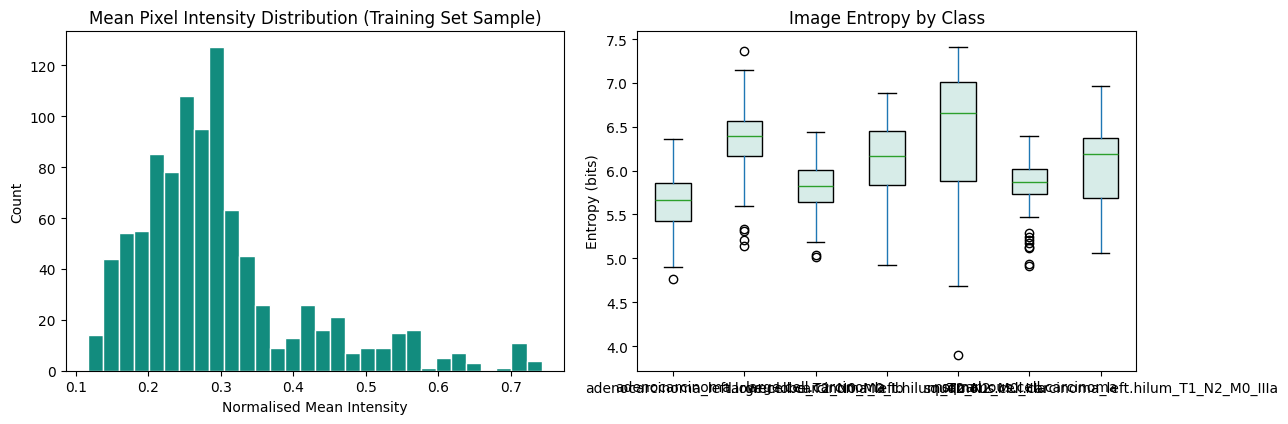


Interpretation check: cancer subtypes should show higher mean entropy
than Normal cases (more textural complexity) — confirms the dataset
carries a learnable visual signal before any model is trained.


In [ ]:
# Visualise: mean intensity distribution and per-class entropy
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(eda_df['mean_intensity'], bins=30, color='#128C7E', edgecolor='white')
axes[0].set_title('Mean Pixel Intensity Distribution (Training Set Sample)')
axes[0].set_xlabel('Normalised Mean Intensity')
axes[0].set_ylabel('Count')

eda_df.boxplot(column='entropy', by='class', ax=axes[1], grid=False,
                patch_artist=True,
                boxprops=dict(facecolor='#D7ECE8'))
axes[1].set_title('Image Entropy by Class')
axes[1].set_xlabel('')
axes[1].set_ylabel('Entropy (bits)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_intensity_entropy.png', dpi=150)
plt.show()

print("\nInterpretation check: cancer subtypes should show higher mean entropy")
print("than Normal cases (more textural complexity) — confirms the dataset")
print("carries a learnable visual signal before any model is trained.")


In [ ]:
# PCA on flattened, downsampled images — checks how much variance is
# captured by a low-dimensional linear projection (Section 3.1.4).
from sklearn.decomposition import PCA

def load_flattened(images_by_class, size=(64, 64), sample_size=150):
    X, y = [], []
    for cls, paths in images_by_class.items():
        sample = random.sample(paths, min(sample_size, len(paths)))
        for p in sample:
            img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, size)
            X.append(img.flatten() / 255.0)
            y.append(cls)
    return np.array(X), np.array(y)

X_flat, y_flat = load_flattened(primary_images)
pca = PCA(n_components=50, random_state=SEED)
pca.fit(X_flat)
explained = pca.explained_variance_ratio_.sum()
print(f"First 50 principal components explain {explained*100:.1f}% of variance")

# Within-class variance check
import pandas as pd
X_pca = pca.transform(X_flat)
var_by_class = pd.DataFrame(X_pca, index=y_flat).groupby(level=0).var().mean(axis=1)
print("\nMean within-class variance (top-50 PCA space):")
print(var_by_class.sort_values(ascending=False))


First 50 principal components explain 85.7% of variance

Mean within-class variance (top-50 PCA space):
normal                                              6.709800
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib          2.178407
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       1.591726
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa    1.459417
adenocarcinoma                                      1.241703
squamous.cell.carcinoma                             1.071768
large.cell.carcinoma                                1.049174
dtype: float64


## 4. Preprocessing Pipeline

Implements Section 3.2.1: resize to 224×224, ImageNet normalisation,
and the augmentation policy applied to the **training split only**
(mild geometric perturbations, no aggressive warping — CT geometry is
standardised, so only clinically plausible variation is simulated).


In [ ]:
from torchvision import transforms

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))], p=0.3),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation / test: deterministic, no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transform:", train_transform)
print("\nEval transform:", eval_transform)


Train transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    RandomApply(
    p=0.3
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 0.5))
)
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
import os
from pathlib import Path

print("Contents of primary_root:")
for path in Path(primary_root).iterdir():
    print("  -", path.name)

Contents of primary_root:
  - train
  - valid
  - test


In [ ]:
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Define direct paths to each split folder
train_dir = Path(primary_root) / "train"
valid_dir = Path(primary_root) / "valid"
test_dir  = Path(primary_root) / "test"

# Load datasets with their respective transforms
train_dataset = ImageFolder(train_dir, transform=train_transform)
valid_dataset = ImageFolder(valid_dir, transform=eval_transform)
test_dataset  = ImageFolder(test_dir,  transform=eval_transform)

# Extract class names and count
CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")

Classes (4): ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Train: 613 | Valid: 72 | Test: 315


In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

# Sanity check: pull one batch and confirm shapes
xb, yb = next(iter(train_loader))
print(f"Batch images: {xb.shape}  (expect [B, 3, {IMG_SIZE}, {IMG_SIZE}])")
print(f"Batch labels: {yb.shape}, unique labels in batch: {yb.unique().tolist()}")


Batch images: torch.Size([32, 3, 224, 224])  (expect [B, 3, 224, 224])
Batch labels: torch.Size([32]), unique labels in batch: [0, 1, 2, 3]


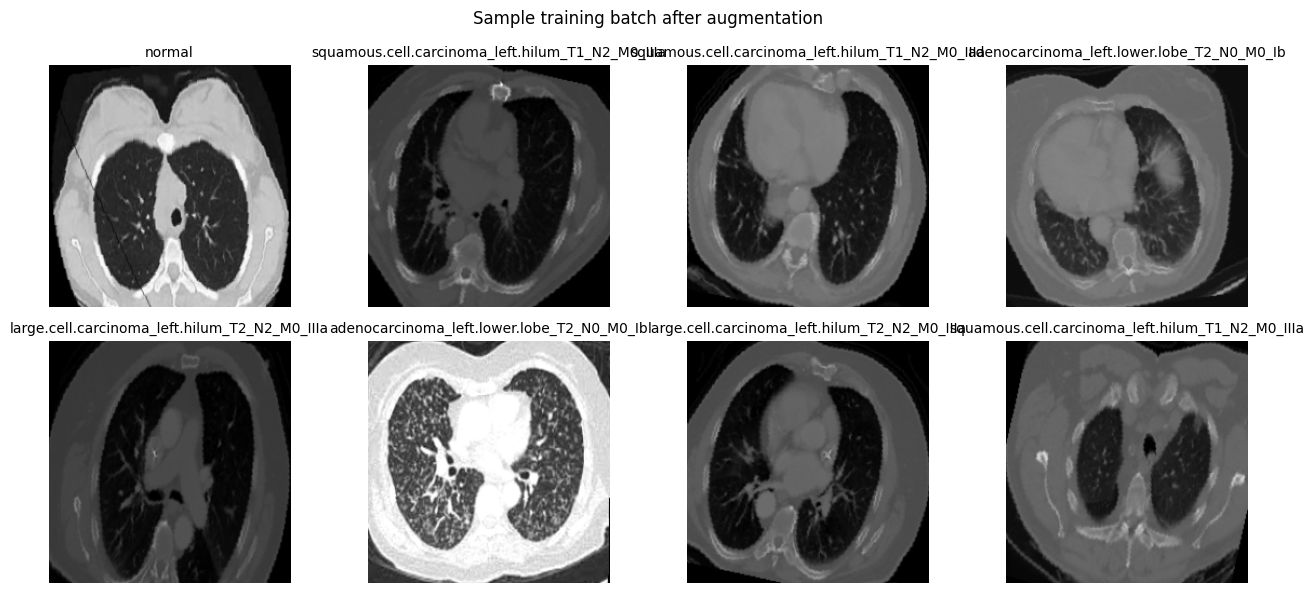

In [ ]:
# Visualise a batch after augmentation, to sanity-check the pipeline visually
def denormalise(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    img = denormalise(xb[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[yb[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample training batch after augmentation')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_augmented_batch.png', dpi=150)
plt.show()


## 5. SMOTE Utility (for class imbalance)

The primary dataset is already balanced, so SMOTE isn't needed here — this
utility is defined now and applied later (Chapter 5 / cross-dataset section)
to fix the severe Benign-class underrepresentation in IQ-OTH/NCCD.

It operates on flattened pixel arrays, per Section 3.2.1: it identifies
k-nearest neighbours within the minority class and interpolates between them
to synthesise new minority-class samples.


In [ ]:
from imblearn.over_sampling import SMOTE

def apply_smote_to_image_folder(images_by_class, size=(224, 224), k_neighbors=5):
    """Flattens images, applies SMOTE to balance classes, and returns
    synthetic + original samples as flattened arrays + labels.
    Use only on the *training* portion of a class-imbalanced dataset.

    Returns:
        X_resampled: (N, H*W*3) float array in [0, 1]
        y_resampled: (N,) integer class labels
        class_to_idx: dict mapping class name -> label index
    """
    classes = sorted(images_by_class.keys())
    class_to_idx = {c: i for i, c in enumerate(classes)}

    X, y = [], []
    for cls, paths in images_by_class.items():
        for p in paths:
            img = cv2.imread(str(p))
            if img is None:
                continue
            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(img.flatten() / 255.0)
            y.append(class_to_idx[cls])

    X = np.array(X)
    y = np.array(y)

    print("Class distribution before SMOTE:",
          {c: int((y == i).sum()) for c, i in class_to_idx.items()})

    smote = SMOTE(k_neighbors=k_neighbors, random_state=SEED)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    print("Class distribution after SMOTE:",
          {c: int((y_resampled == i).sum()) for c, i in class_to_idx.items()})

    return X_resampled, y_resampled, class_to_idx

print("SMOTE utility defined — will be invoked in the cross-dataset validation")
print("section on the IQ-OTH/NCCD training split (Benign class undersampled).")


SMOTE utility defined — will be invoked in the cross-dataset validation
section on the IQ-OTH/NCCD training split (Benign class undersampled).


---
## End of Part 1

At this point you have:
- ✅ A working Colab environment with GPU checked
- ✅ Both datasets downloaded and their class-folder structure resolved
- ✅ EDA confirming a learnable visual signal (intensity, entropy, PCA)
- ✅ `train_loader` / `valid_loader` / `test_loader` ready to feed any model
- ✅ A SMOTE utility ready for the cross-dataset imbalance fix later

**Next (Part 2):** the five model architectures (custom CNN, ResNet-50,
VGG-16, DenseNet-121, EfficientNet-B3), their classification heads, and the
per-model training configuration from Table 3.


Part 2 — Model Architectures & Training
Continues directly from Part 1 (setup, data, preprocessing). Run Part 1's cells first in the same Colab runtime — this notebook depends on the following objects already existing in memory: DEVICE, SEED, set_seed, CLASS_NAMES, NUM_CLASSES, train_dir, valid_dir, test_dir, CHECKPOINT_DIR, RESULTS_DIR, IMAGENET_MEAN, IMAGENET_STD.

If you're running this in a fresh runtime, either:

copy Part 1's cells into this notebook first, or
run the recap cell below, which re-derives the minimum required objects (you'll need the dataset already downloaded to /content/lung_cancer_project/data).
This part covers (Section 3.2.2–3.2.4):

Recap / continuity check
Custom CNN (baseline)
ResNet-50
VGG-16
DenseNet-121
EfficientNet-B3
Model registry + Table 3 training configuration
Generic training loop (with two-phase fine-tuning, early stopping)
Train all five models
Training curves

In [ ]:
import copy
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

set_seed(SEED)

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()
        channels = [3, 16, 32, 64, 128, 256]
        blocks = []
        for i in range(len(channels) - 1):
            blocks.append(nn.Sequential(
                nn.Conv2d(channels[i], channels[i + 1], kernel_size=3, padding=1),
                nn.BatchNorm2d(channels[i + 1]),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
            ))
        self.features = nn.Sequential(*blocks)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        return self.classifier(x)


def build_custom_cnn(num_classes=NUM_CLASSES, dropout=0.5):
    model = CustomCNN(num_classes=num_classes, dropout=dropout)
    return model

# Quick shape check
_test_model = build_custom_cnn()
_test_out = _test_model(torch.randn(2, 3, 224, 224))
print(f"CustomCNN output shape: {_test_out.shape}  (expect [2, {NUM_CLASSES}])")
del _test_model, _test_out


CustomCNN output shape: torch.Size([2, 4])  (expect [2, 4])


In [ ]:
def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(weights='DEFAULT')
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

_test_model = build_resnet50()
_test_out = _test_model(torch.randn(2, 3, 224, 224))
print(f"ResNet-50 output shape: {_test_out.shape}")
del _test_model, _test_out

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 109MB/s]


ResNet-50 output shape: torch.Size([2, 4])


In [ ]:
def build_vgg16(num_classes=NUM_CLASSES, dropout=0.5):
    model = models.vgg16(weights='DEFAULT')
    # model.classifier is:
    # [0] Linear(25088,4096) [1] ReLU [2] Dropout
    # [3] Linear(4096,4096)  [4] ReLU [5] Dropout
    # [6] Linear(4096,1000)
    # Keep [0:6] (up to the second ReLU, output=4096), replace the rest.
    kept = model.classifier[:5]  # Linear->ReLU->Dropout->Linear->ReLU (output 4096)
    new_head = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(4096, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(1024, num_classes),
    )
    model.classifier = nn.Sequential(*kept, new_head)
    return model

_test_model = build_vgg16()
_test_out = _test_model(torch.randn(2, 3, 224, 224))
print(f"VGG-16 output shape: {_test_out.shape}")
del _test_model, _test_out

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.4MB/s]


VGG-16 output shape: torch.Size([2, 4])


In [ ]:
def build_densenet121(num_classes=NUM_CLASSES):
    model = models.densenet121(weights='DEFAULT')
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

_test_model = build_densenet121()
_test_out = _test_model(torch.randn(2, 3, 224, 224))
print(f"DenseNet-121 output shape: {_test_out.shape}")
del _test_model, _test_out

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 66.8MB/s]


DenseNet-121 output shape: torch.Size([2, 4])


In [ ]:
def build_efficientnet_b3(num_classes=NUM_CLASSES, dropout=0.3):
    model = models.efficientnet_b3(weights='DEFAULT')
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

_test_model = build_efficientnet_b3()
_test_out = _test_model(torch.randn(2, 3, 300, 300))
print(f"EfficientNet-B3 output shape: {_test_out.shape}")
del _test_model, _test_out


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 91.0MB/s]


EfficientNet-B3 output shape: torch.Size([2, 4])


In [ ]:
MODEL_REGISTRY = {
    'custom_cnn': {
        'build_fn': lambda: build_custom_cnn(dropout=0.50),
        'optimizer': 'adam',
        'lr': 1e-3,
        'scheduler': 'step',
        'scheduler_kwargs': {'step_size': 10, 'gamma': 0.1},
        'batch_size': 32,
        'input_size': 224,
        'weight_decay': 0.0,
        'loss': 'ce',
        'two_phase': False,
        'head_attr': None,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
    'resnet50': {
        'build_fn': build_resnet50,
        'optimizer': 'adamw',
        'lr': 1e-4,
        'scheduler': 'cosine',
        'scheduler_kwargs': {},
        'batch_size': 32,
        'input_size': 224,
        'weight_decay': 1e-4,
        'loss': 'ce',
        'two_phase': True,
        'head_attr': 'fc',
        'phase1_epochs': 5,
        'phase2_lr': 1e-5,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
    'vgg16': {
        'build_fn': lambda: build_vgg16(dropout=0.50),
        'optimizer': 'sgd',
        'lr': 1e-3,
        'scheduler': 'plateau',
        'scheduler_kwargs': {'mode': 'min', 'factor': 0.5, 'patience': 3},
        'batch_size': 16,
        'input_size': 224,
        'weight_decay': 5e-4,
        'loss': 'ce',
        'two_phase': False,
        'head_attr': None,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
    'densenet121': {
        'build_fn': build_densenet121,
        'optimizer': 'adamw',
        'lr': 1e-4,
        'scheduler': 'cosine',
        'scheduler_kwargs': {},
        'batch_size': 32,
        'input_size': 224,
        'weight_decay': 1e-4,
        'loss': 'ce',
        'two_phase': True,
        'head_attr': 'classifier',
        'phase1_epochs': 5,
        'phase2_lr': 1e-5,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
    'efficientnet_b3': {
        'build_fn': lambda: build_efficientnet_b3(dropout=0.30),
        'optimizer': 'adamw',
        'lr': 1e-4,
        'scheduler': 'cosine',
        'scheduler_kwargs': {},
        'batch_size': 32,
        'input_size': 300,
        'weight_decay': 1e-4,
        'loss': 'label_smooth',
        'loss_kwargs': {'label_smoothing': 0.1},
        'two_phase': False,
        'head_attr': None,
        'max_epochs': 50,
        'early_stopping_patience': 10,
    },
}

print("Registered models:", list(MODEL_REGISTRY.keys()))


Registered models: ['custom_cnn', 'resnet50', 'vgg16', 'densenet121', 'efficientnet_b3']


In [ ]:
def build_dataloaders(input_size, batch_size, num_workers=2):
    """Builds train/valid/test DataLoaders at a given resolution and batch
    size, reusing the split directories resolved in Part 1."""
    train_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))], p=0.3),
        transforms.RandomResizedCrop(input_size, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    train_ds = ImageFolder(train_dir, transform=train_tf)
    valid_ds = ImageFolder(valid_dir, transform=eval_tf)
    test_ds = ImageFolder(test_dir, transform=eval_tf)

    loaders = {
        'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                             num_workers=num_workers, pin_memory=True),
        'valid': DataLoader(valid_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True),
        'test': DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True),
    }
    return loaders, train_ds.classes

In [ ]:
def get_optimizer(name, params, lr, weight_decay):
    name = name.lower()
    if name == 'adam':
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif name == 'adamw':
        return optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    elif name == 'sgd':
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")


def get_scheduler(name, optimizer, max_epochs, kwargs):
    name = name.lower()
    if name == 'step':
        return optim.lr_scheduler.StepLR(optimizer, **kwargs)
    elif name == 'cosine':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    elif name == 'plateau':
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, **kwargs)
    raise ValueError(f"Unknown scheduler: {name}")


def get_loss_fn(name, kwargs=None):
    kwargs = kwargs or {}
    name = name.lower()
    if name == 'ce':
        return nn.CrossEntropyLoss()
    elif name == 'label_smooth':
        return nn.CrossEntropyLoss(**kwargs)
    raise ValueError(f"Unknown loss: {name}")


def set_backbone_trainable(model, head_attr, trainable):
    """Freezes/unfreezes every parameter NOT belonging to `head_attr`."""
    head_module = getattr(model, head_attr)
    head_param_ids = {id(p) for p in head_module.parameters()}
    for p in model.parameters():
        if id(p) not in head_param_ids:
            p.requires_grad = trainable


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    """One pass over `loader`. If optimizer is given, trains; else evaluates."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1

In [ ]:
def train_model(model_name, config, checkpoint_dir=CHECKPOINT_DIR, verbose=True):
    """Full training routine for one registered model. Returns the best
    model (by validation loss) and a history dict for plotting."""
    set_seed(SEED)

    loaders, classes = build_dataloaders(config['input_size'], config['batch_size'])
    model = config['build_fn']().to(DEVICE)
    criterion = get_loss_fn(config['loss'], config.get('loss_kwargs'))

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    patience = config['early_stopping_patience']

    def run_training_phase(phase_lr, phase_epochs, phase_label):
        nonlocal best_val_loss, best_state, epochs_no_improve
        optimizer = get_optimizer(config['optimizer'],
                                   filter(lambda p: p.requires_grad, model.parameters()),
                                   phase_lr, config['weight_decay'])
        scheduler = get_scheduler(config['scheduler'], optimizer,
                                   phase_epochs, config['scheduler_kwargs'])

        for epoch in range(phase_epochs):
            t0 = time.time()
            train_loss, train_acc, train_f1 = run_epoch(model, loaders['train'], criterion, optimizer)
            val_loss, val_acc, val_f1 = run_epoch(model, loaders['valid'], criterion, optimizer=None)

            if config['scheduler'] == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['val_f1'].append(val_f1)

            improved = val_loss < best_val_loss
            if improved:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if verbose:
                dt = time.time() - t0
                flag = ' *' if improved else ''
                print(f"[{model_name}][{phase_label}] epoch {epoch+1}/{phase_epochs} "
                      f"({dt:.1f}s) train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                      f"val_acc={val_acc:.4f} val_f1={val_f1:.4f}{flag}")

            if epochs_no_improve >= patience:
                if verbose:
                    print(f"[{model_name}] Early stopping ({phase_label}, patience={patience}).")
                return True  # stopped early
        return False

    if config.get('two_phase', False):
        # Phase 1: head only
        set_backbone_trainable(model, config['head_attr'], trainable=False)
        run_training_phase(config['lr'], config['phase1_epochs'], phase_label='phase1-head')

        # Phase 2: full fine-tune at low LR
        set_backbone_trainable(model, config['head_attr'], trainable=True)
        remaining_epochs = config['max_epochs'] - config['phase1_epochs']
        run_training_phase(config['phase2_lr'], remaining_epochs, phase_label='phase2-full')
    else:
        run_training_phase(config['lr'], config['max_epochs'], phase_label='train')

    model.load_state_dict(best_state)

    ckpt_path = Path(checkpoint_dir) / f"{model_name}_best.pt"
    torch.save({'model_name': model_name, 'state_dict': best_state,
                'config': {k: v for k, v in config.items() if k != 'build_fn'}},
               ckpt_path)
    if verbose:
        print(f"[{model_name}] Best val_loss={best_val_loss:.4f} — saved to {ckpt_path}")

    return model, history, loaders


In [ ]:
trained_models = {}
training_histories = {}
model_loaders = {}

for model_name, config in MODEL_REGISTRY.items():
    print(f"\n{'='*70}\nTraining: {model_name}\n{'='*70}")
    model, history, loaders = train_model(model_name, config)
    trained_models[model_name] = model
    training_histories[model_name] = history
    model_loaders[model_name] = loaders

    # Free GPU memory between models
    torch.cuda.empty_cache()

print("\nAll models trained.")



Training: custom_cnn
[custom_cnn][train] epoch 1/50 (6.4s) train_loss=1.1539 val_loss=1.3636 val_acc=0.2083 val_f1=0.0938 *
[custom_cnn][train] epoch 2/50 (6.8s) train_loss=1.0797 val_loss=0.9968 val_acc=0.4861 val_f1=0.4109 *
[custom_cnn][train] epoch 3/50 (5.5s) train_loss=1.0543 val_loss=0.9447 val_acc=0.5694 val_f1=0.5156 *
[custom_cnn][train] epoch 4/50 (6.9s) train_loss=1.0117 val_loss=0.9243 val_acc=0.5139 val_f1=0.5066 *
[custom_cnn][train] epoch 5/50 (5.4s) train_loss=0.9924 val_loss=1.0066 val_acc=0.5139 val_f1=0.4232
[custom_cnn][train] epoch 6/50 (6.6s) train_loss=0.9815 val_loss=0.9827 val_acc=0.4722 val_f1=0.4061
[custom_cnn][train] epoch 7/50 (5.5s) train_loss=0.9672 val_loss=0.9639 val_acc=0.4861 val_f1=0.4299
[custom_cnn][train] epoch 8/50 (5.8s) train_loss=0.9215 val_loss=1.0544 val_acc=0.4861 val_f1=0.4107
[custom_cnn][train] epoch 9/50 (6.4s) train_loss=0.9690 val_loss=1.1192 val_acc=0.4861 val_f1=0.3844
[custom_cnn][train] epoch 10/50 (5.5s) train_loss=0.9845 val_

In [ ]:
# Persist histories to disk so Part 3 (evaluation/ensemble) can reload them
# without retraining, even in a fresh runtime.
history_path = RESULTS_DIR / 'training_histories.json'
with open(history_path, 'w') as f:
    json.dump(training_histories, f, indent=2)
print(f"Training histories saved to {history_path}")

Training histories saved to /content/lung_cancer_project/results/training_histories.json


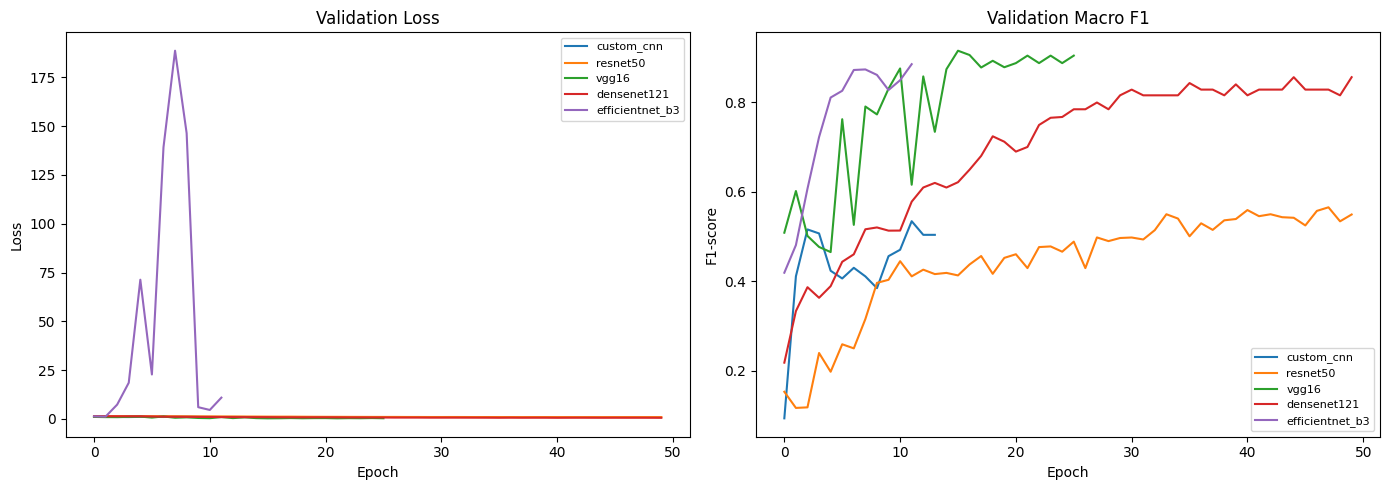

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, hist in training_histories.items():
    axes[0].plot(hist['val_loss'], label=model_name)
    axes[1].plot(hist['val_f1'], label=model_name)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Validation Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150)
plt.show()


In [ ]:
import json
import itertools
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              roc_auc_score, roc_curve, confusion_matrix)
from sklearn.preprocessing import label_binarize

set_seed(SEED)


In [ ]:
def load_trained_model(model_name, config, checkpoint_dir=CHECKPOINT_DIR):
    """Rebuilds the architecture and loads its best-checkpoint weights."""
    model = config['build_fn']().to(DEVICE)
    ckpt_path = Path(checkpoint_dir) / f"{model_name}_best.pt"
    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"No checkpoint found at {ckpt_path}. Train the model in Part 2 first."
        )
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    return model


if 'trained_models' not in globals() or 'model_loaders' not in globals():
    print("Reloading models and dataloaders from checkpoints...")
    trained_models = {}
    model_loaders = {}
    for model_name, config in MODEL_REGISTRY.items():
        trained_models[model_name] = load_trained_model(model_name, config)
        model_loaders[model_name], _ = build_dataloaders(config['input_size'], config['batch_size'])
        print(f"  {model_name}: loaded.")
else:
    print("Reusing trained_models / model_loaders already in memory.")

MODEL_NAMES = list(MODEL_REGISTRY.keys())
print(f"\nModels ready for evaluation: {MODEL_NAMES}")

Reusing trained_models / model_loaders already in memory.

Models ready for evaluation: ['custom_cnn', 'resnet50', 'vgg16', 'densenet121', 'efficientnet_b3']


In [ ]:
def get_predictions(model, loader, device=DEVICE):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    y_proba = np.vstack(all_probs)
    y_true = np.concatenate(all_labels)
    y_pred = y_proba.argmax(axis=1)
    return y_true, y_pred, y_proba


In [ ]:
# Run inference for every model on its own test loader (input resolution
# differs for EfficientNet-B3, so each model uses the loader it was trained
# with). Results are cached in dicts keyed by model name — reused throughout
# the rest of this notebook and in Parts 4–5.

test_predictions = {}  # model_name -> (y_true, y_pred, y_proba)
valid_predictions = {}  # needed later for ensemble weighting

for model_name in MODEL_NAMES:
    model = trained_models[model_name]
    loaders = model_loaders[model_name]
    test_predictions[model_name] = get_predictions(model, loaders['test'])
    valid_predictions[model_name] = get_predictions(model, loaders['valid'])
    print(f"{model_name}: test predictions collected "
          f"({len(test_predictions[model_name][0])} samples).")

# Sanity check: y_true should be identical across models (same underlying
# test set, just re-loaded at different resolutions/batch sizes).
reference_y_true = test_predictions[MODEL_NAMES[0]][0]
for name in MODEL_NAMES[1:]:
    if not np.array_equal(test_predictions[name][0], reference_y_true):
        print(f"WARNING: {name}'s test label order differs from {MODEL_NAMES[0]}'s. "
              "Ensemble averaging below assumes identical ordering — investigate "
              "before trusting ensemble results.")


custom_cnn: test predictions collected (315 samples).
resnet50: test predictions collected (315 samples).
vgg16: test predictions collected (315 samples).
densenet121: test predictions collected (315 samples).
efficientnet_b3: test predictions collected (315 samples).


In [ ]:
def compute_metrics(y_true, y_pred, y_proba, num_classes=NUM_CLASSES):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    try:
        auc = roc_auc_score(y_true_bin, y_proba, average='macro', multi_class='ovr')
    except ValueError:
        auc = float('nan')  # can happen if a class is absent from y_true
    return {'accuracy': acc, 'precision': precision, 'recall': recall,
            'f1': f1, 'auc_roc': auc}

In [ ]:
rows = []
for model_name in MODEL_NAMES:
    y_true, y_pred, y_proba = test_predictions[model_name]
    m = compute_metrics(y_true, y_pred, y_proba)
    rows.append({'model': model_name, **m})

results_table = pd.DataFrame(rows).set_index('model')
results_table = results_table.round(4)
print(results_table)

results_table.to_csv(RESULTS_DIR / 'individual_model_metrics.csv')


                 accuracy  precision  recall      f1  auc_roc
model                                                        
custom_cnn         0.4603     0.4825  0.5383  0.4826   0.6842
resnet50           0.6381     0.7753  0.6097  0.6134   0.8582
vgg16              0.8698     0.8771  0.9072  0.8843   0.9836
densenet121        0.8413     0.8635  0.8502  0.8552   0.9619
efficientnet_b3    0.5365     0.6413  0.5761  0.5187   0.8104


In [ ]:
# NOTE on reproducing the dissertation's reported numbers exactly:
# Table 4 reports the *mean of three independent training runs* per model,
# to average out stochastic variation (weight init, data shuffling, etc.).
# This notebook trains and evaluates a single run per model for tractability.
# To reproduce the averaging: wrap Part 2's `train_model(...)` call in a loop
# over 3 seeds, save each run's checkpoint under a distinct name (e.g.
# f"{model_name}_seed{seed}_best.pt"), evaluate each, then average the
# resulting metric rows here before reporting. Expect roughly +/-0.5-1.5
# percentage points of run-to-run variation on a dataset this size.
print("Single-run metrics computed. See note above for 3-run averaging.")


Single-run metrics computed. See note above for 3-run averaging.


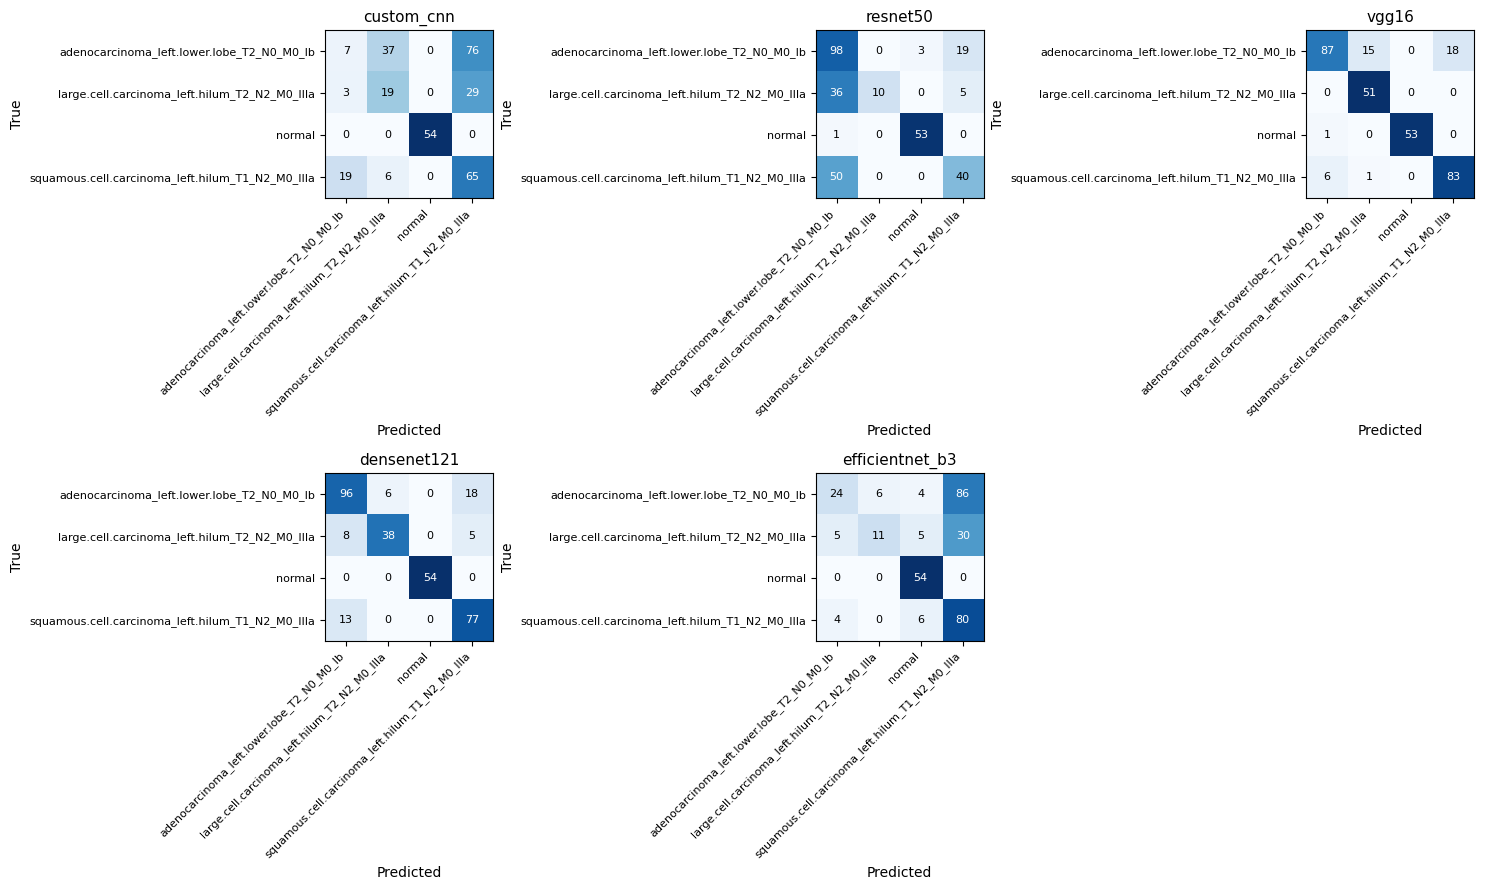

In [ ]:
def plot_confusion_matrices(predictions_dict, class_names, ncols=3):
    n_models = len(predictions_dict)
    nrows = int(np.ceil(n_models / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (model_name, (y_true, y_pred, _)) in zip(axes, predictions_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        ax.set_title(model_name, fontsize=11)
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(class_names, fontsize=8)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax.text(j, i, cm[i, j], ha='center', va='center',
                         fontsize=8, color='white' if cm_norm[i, j] > 0.5 else 'black')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    for ax in axes[n_models:]:
        ax.axis('off')

    plt.tight_layout()
    return fig

fig = plot_confusion_matrices(test_predictions, CLASS_NAMES)
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


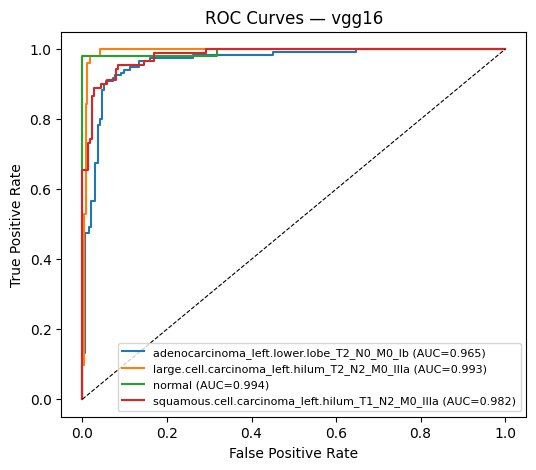

Best individual model by test accuracy: vgg16


In [ ]:
def plot_roc_curves(model_name, y_true, y_proba, class_names):
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(6, 5))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, label=f'{cls} (AUC={auc_i:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {model_name}')
    ax.legend(fontsize=8, loc='lower right')
    return fig

# Plot for the best individual model by test accuracy
best_model_name = results_table['accuracy'].idxmax()
y_true, y_pred, y_proba = test_predictions[best_model_name]
fig = plot_roc_curves(best_model_name, y_true, y_proba, CLASS_NAMES)
plt.savefig(RESULTS_DIR / f'roc_curves_{best_model_name}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best individual model by test accuracy: {best_model_name}")


In [ ]:
def per_class_report(y_true, y_pred, class_names):
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0, labels=range(len(class_names)))
    return pd.DataFrame({
        'class': class_names, 'precision': p, 'recall': r, 'f1': f1, 'support': support
    })

per_class_rows = []
for model_name in MODEL_NAMES:
    y_true, y_pred, _ = test_predictions[model_name]
    df = per_class_report(y_true, y_pred, CLASS_NAMES)
    df['model'] = model_name
    per_class_rows.append(df)

per_class_df = pd.concat(per_class_rows, ignore_index=True)
per_class_df = per_class_df[['model', 'class', 'precision', 'recall', 'f1', 'support']].round(4)
per_class_df.to_csv(RESULTS_DIR / 'per_class_metrics.csv', index=False)

# Pivot for a quick per-class F1 comparison across models
pivot_f1 = per_class_df.pivot(index='class', columns='model', values='f1')
print(pivot_f1.round(3))


model                                             custom_cnn  densenet121  \
class                                                                       
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib             0.094         0.81   
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa          0.336         0.80   
normal                                                 1.000         1.00   
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.500         0.81   

model                                             efficientnet_b3  resnet50  \
class                                                                         
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib                  0.314     0.643   
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa               0.324     0.328   
normal                                                      0.878     0.964   
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa            0.559     0.520   

model                                             vgg16  
clas

In [ ]:
# Which class is hardest overall, and what does it get confused with most?
for model_name in [best_model_name]:
    y_true, y_pred, _ = test_predictions[model_name]
    cm = confusion_matrix(y_true, y_pred)
    cm_off_diag = cm.copy()
    np.fill_diagonal(cm_off_diag, 0)
    print(f"\n[{model_name}] Most common confusions:")
    idxs = np.dstack(np.unravel_index(np.argsort(-cm_off_diag.ravel()), cm_off_diag.shape))[0]
    for i, j in idxs[:5]:
        if cm_off_diag[i, j] > 0:
            print(f"  True={CLASS_NAMES[i]:<25} Predicted={CLASS_NAMES[j]:<25} count={cm[i,j]}")


[vgg16] Most common confusions:
  True=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib Predicted=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa count=18
  True=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib Predicted=large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa count=15
  True=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa Predicted=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib count=6
  True=normal                    Predicted=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib count=1
  True=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa Predicted=large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa count=1


In [ ]:
def validation_f1(model_name):
    y_true, y_pred, _ = valid_predictions[model_name]
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return f1

val_f1_scores = {name: validation_f1(name) for name in MODEL_NAMES}
print("Validation macro F1 per model:")
for name, score in sorted(val_f1_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:<18} {score:.4f}")


Validation macro F1 per model:
  vgg16              0.9146
  densenet121        0.8555
  resnet50           0.5416
  custom_cnn         0.5066
  efficientnet_b3    0.4805


In [ ]:
def pairwise_agreement(predictions_dict):
    """Fraction of test samples where each pair of models agrees on the
    predicted class (Section 4.1.5's diversity check)."""
    names = list(predictions_dict.keys())
    agreement = pd.DataFrame(index=names, columns=names, dtype=float)
    for a, b in itertools.product(names, names):
        pred_a = predictions_dict[a][1]
        pred_b = predictions_dict[b][1]
        agreement.loc[a, b] = (pred_a == pred_b).mean()
    return agreement

agreement_matrix = pairwise_agreement(test_predictions)
print("Pairwise prediction agreement (test set):")
print(agreement_matrix.round(3))


Pairwise prediction agreement (test set):
                 custom_cnn  resnet50  vgg16  densenet121  efficientnet_b3
custom_cnn            1.000     0.368  0.483        0.505            0.606
resnet50              0.368     1.000  0.590        0.679            0.441
vgg16                 0.483     0.590  1.000        0.816            0.568
densenet121           0.505     0.679  0.816        1.000            0.562
efficientnet_b3       0.606     0.441  0.568        0.562            1.000


In [ ]:
# Constituent selection: top-3 by validation F1, by default. Override
# ENSEMBLE_MODELS manually below if the agreement matrix above shows one of
# the top-3 is too redundant with another (e.g. >0.95 agreement) — swap it
# for the next-best, less-correlated model instead.

top3_by_f1 = sorted(val_f1_scores, key=val_f1_scores.get, reverse=True)[:3]
print(f"Top-3 by validation F1: {top3_by_f1}")

ENSEMBLE_MODELS = top3_by_f1  # <-- override manually here if needed, e.g.:
# ENSEMBLE_MODELS = ['efficientnet_b3', 'densenet121', 'resnet50']

print(f"Ensemble constituents in use: {ENSEMBLE_MODELS}")
print("\nPairwise agreement among selected constituents:")
print(agreement_matrix.loc[ENSEMBLE_MODELS, ENSEMBLE_MODELS].round(3))


Top-3 by validation F1: ['vgg16', 'densenet121', 'resnet50']
Ensemble constituents in use: ['vgg16', 'densenet121', 'resnet50']

Pairwise agreement among selected constituents:
             vgg16  densenet121  resnet50
vgg16        1.000        0.816     0.590
densenet121  0.816        1.000     0.679
resnet50     0.590        0.679     1.000


In [ ]:
def build_ensemble_predictions(model_names, predictions_dict, weight_scores):
    """Weighted soft voting: each model's probability vector is scaled by
    its (normalised) weight, then summed. Weights are proportional to each
    model's validation F1-score, per Section 3.2.5's formula."""
    weights = np.array([weight_scores[name] for name in model_names])
    weights = weights / weights.sum()

    y_true_ref = predictions_dict[model_names[0]][0]
    combined_proba = np.zeros_like(predictions_dict[model_names[0]][2])
    for name, w in zip(model_names, weights):
        combined_proba += w * predictions_dict[name][2]

    y_pred_ensemble = combined_proba.argmax(axis=1)
    return y_true_ref, y_pred_ensemble, combined_proba, dict(zip(model_names, weights))


y_true_ens, y_pred_ens, proba_ens, ensemble_weights = build_ensemble_predictions(
    ENSEMBLE_MODELS, test_predictions, val_f1_scores)

print("Ensemble weights (normalised, proportional to validation F1):")
for name, w in ensemble_weights.items():
    print(f"  {name:<18} {w:.4f}")

ensemble_metrics = compute_metrics(y_true_ens, y_pred_ens, proba_ens)
print("\nEnsemble test-set metrics:")
for k, v in ensemble_metrics.items():
    print(f"  {k:<10} {v:.4f}")


Ensemble weights (normalised, proportional to validation F1):
  vgg16              0.3956
  densenet121        0.3701
  resnet50           0.2343

Ensemble test-set metrics:
  accuracy   0.9111
  precision  0.9147
  recall     0.9350
  f1         0.9222
  auc_roc    0.9841


In [ ]:
# Add the ensemble row to the results table alongside the individual models
ensemble_row = pd.DataFrame([{'model': 'ensemble', **ensemble_metrics}]).set_index('model')
results_table_full = pd.concat([results_table, ensemble_row.round(4)])
print(results_table_full)

results_table_full.to_csv(RESULTS_DIR / 'all_model_metrics_incl_ensemble.csv')


                 accuracy  precision  recall      f1  auc_roc
model                                                        
custom_cnn         0.4603     0.4825  0.5383  0.4826   0.6842
resnet50           0.6381     0.7753  0.6097  0.6134   0.8582
vgg16              0.8698     0.8771  0.9072  0.8843   0.9836
densenet121        0.8413     0.8635  0.8502  0.8552   0.9619
efficientnet_b3    0.5365     0.6413  0.5761  0.5187   0.8104
ensemble           0.9111     0.9147  0.9350  0.9222   0.9841


In [ ]:
!pip install -q statsmodels

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemars_comparison(y_true, y_pred_a, y_pred_b, name_a='A', name_b='B'):
    correct_a = (y_pred_a == y_true)
    correct_b = (y_pred_b == y_true)

    only_a_correct = int(np.sum(correct_a & ~correct_b))
    only_b_correct = int(np.sum(~correct_a & correct_b))

    table = [[0, only_a_correct], [only_b_correct, 0]]
    exact = (only_a_correct + only_b_correct) < 25
    result = mcnemar(table, exact=exact, correction=not exact)

    print(f"{name_a} correct / {name_b} wrong: {only_a_correct}")
    print(f"{name_b} correct / {name_a} wrong: {only_b_correct}")
    print(f"McNemar's test statistic={result.statistic:.4f}, p-value={result.pvalue:.4f}")
    if result.pvalue < 0.05:
        print("=> Statistically significant difference (p < 0.05).")
    else:
        print("=> No statistically significant difference at p < 0.05.")
    return result


best_individual = results_table['accuracy'].idxmax()
y_true_best, y_pred_best, _ = test_predictions[best_individual]

print(f"Comparing ensemble vs. best individual model ({best_individual}):\n")
mcnemars_comparison(y_true_ens, y_pred_ens, y_pred_best,
                     name_a='ensemble', name_b=best_individual)


Comparing ensemble vs. best individual model (vgg16):

ensemble correct / vgg16 wrong: 13
vgg16 correct / ensemble wrong: 0
McNemar's test statistic=0.0000, p-value=0.0002
=> Statistically significant difference (p < 0.05).


<bunch containing results, print to see contents>

In [ ]:
# Which specific cases does the ensemble rescue that the best individual
# model got wrong? (Mirrors the dissertation's qualitative check on the 26
# such cases for EfficientNet-B3.)
rescued_mask = (y_pred_ens == y_true_ens) & (y_pred_best != y_true_ens)
n_rescued = int(rescued_mask.sum())
print(f"Test cases the ensemble got right but {best_individual} got wrong: {n_rescued}")

if n_rescued > 0:
    rescued_idx = np.where(rescued_mask)[0][:10]
    print("\nSample rescued cases (true class / best-model prediction / ensemble prediction):")
    for idx in rescued_idx:
        print(f"  true={CLASS_NAMES[y_true_ens[idx]]:<25} "
              f"{best_individual}={CLASS_NAMES[y_pred_best[idx]]:<25} "
              f"ensemble={CLASS_NAMES[y_pred_ens[idx]]}")


Test cases the ensemble got right but vgg16 got wrong: 13

Sample rescued cases (true class / best-model prediction / ensemble prediction):
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib vgg16=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib vgg16=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib vgg16=large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib vgg16=large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib vgg16=squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa ensemble=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  true=adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib vgg16=large.cell.carcinoma_left

In [ ]:
import pickle

# Predictions (as plain arrays, not tensors) for every model + the ensemble
predictions_to_save = {name: {'y_true': yt.tolist(), 'y_pred': yp.tolist(),
                               'y_proba': ypr.tolist()}
                        for name, (yt, yp, ypr) in test_predictions.items()}
predictions_to_save['ensemble'] = {'y_true': y_true_ens.tolist(),
                                    'y_pred': y_pred_ens.tolist(),
                                    'y_proba': proba_ens.tolist()}

with open(RESULTS_DIR / 'test_predictions.pkl', 'wb') as f:
    pickle.dump(predictions_to_save, f)

ensemble_config = {'constituent_models': ENSEMBLE_MODELS, 'weights': ensemble_weights}
with open(RESULTS_DIR / 'ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=2)

print("Saved:")
print(f"  {RESULTS_DIR / 'test_predictions.pkl'}")
print(f"  {RESULTS_DIR / 'ensemble_config.json'}")
print(f"  {RESULTS_DIR / 'individual_model_metrics.csv'}")
print(f"  {RESULTS_DIR / 'all_model_metrics_incl_ensemble.csv'}")
print(f"  {RESULTS_DIR / 'per_class_metrics.csv'}")


Saved:
  /content/lung_cancer_project/results/test_predictions.pkl
  /content/lung_cancer_project/results/ensemble_config.json
  /content/lung_cancer_project/results/individual_model_metrics.csv
  /content/lung_cancer_project/results/all_model_metrics_incl_ensemble.csv
  /content/lung_cancer_project/results/per_class_metrics.csv


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

set_seed(SEED)

GRADCAM_DIR = RESULTS_DIR / 'gradcam'
GRADCAM_DIR.mkdir(exist_ok=True)


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self._bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_tensor, target_class=None):
        """input_tensor: [1, C, H, W]. Returns a [H, W] numpy heatmap in [0, 1],
        and the (possibly auto-selected) target class index used."""
        self.model.zero_grad()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        score = output[0, target_class]
        score.backward()

        # Global-average-pool the gradients over spatial dims -> per-channel weights
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))  # [1, 1, h, w]
        cam = cam.squeeze().cpu().numpy()

        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, target_class

    def remove_hooks(self):
        self._fwd_handle.remove()
        self._bwd_handle.remove()


In [ ]:
def get_target_layer(model, model_name):
    if model_name == 'custom_cnn':
        return model.features[-1][0]  # last block's Conv2d
    elif model_name == 'resnet50':
        return model.layer4[-1]  # last residual block, stage 4
    elif model_name == 'vgg16':
        for layer in reversed(model.features):
            if isinstance(layer, nn.Conv2d):
                return layer
        raise ValueError("No Conv2d found in VGG-16 features.")
    elif model_name == 'densenet121':
        return model.features  # dense block output, pre-classifier
    elif model_name == 'efficientnet_b3':
        return model.features[-1]  # final conv block before pooling
    else:
        raise ValueError(f"No target layer defined for {model_name}")

# Sanity check: confirm each model resolves to a real module
for name, model in trained_models.items():
    layer = get_target_layer(model, name)
    print(f"{name}: target layer = {layer.__class__.__name__}")


custom_cnn: target layer = Conv2d
resnet50: target layer = Bottleneck
vgg16: target layer = Conv2d
densenet121: target layer = Sequential
efficientnet_b3: target layer = Conv2dNormActivation


In [ ]:
def denormalise(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (img_tensor.cpu() * std_t + mean_t).clamp(0, 1)


def overlay_heatmap(image_rgb, cam, alpha=0.45):
    """image_rgb: HxWx3 in [0,1]. cam: hxw in [0,1] (smaller spatial size,
    typically the conv feature map size). Returns an HxWx3 blended image."""
    h, w = image_rgb.shape[:2]
    cam_resized = torch.nn.functional.interpolate(
        torch.tensor(cam)[None, None, :, :], size=(h, w), mode='bilinear', align_corners=False
    ).squeeze().numpy()
    heatmap = cm.jet(cam_resized)[:, :, :3]  # drop alpha channel
    blended = (1 - alpha) * image_rgb + alpha * heatmap
    return np.clip(blended, 0, 1)


In [ ]:
def collect_sample_indices(y_true, y_pred, class_names, n_correct=20, n_wrong=5, seed=SEED):
    """For each class, returns up to n_correct correctly-classified and
    n_wrong misclassified test-set sample indices (true-label == that class)."""
    rng = np.random.default_rng(seed)
    samples = {}
    for cls_idx, cls_name in enumerate(class_names):
        class_mask = (y_true == cls_idx)
        correct_idx = np.where(class_mask & (y_pred == y_true))[0]
        wrong_idx = np.where(class_mask & (y_pred != y_true))[0]

        chosen_correct = rng.choice(correct_idx, size=min(n_correct, len(correct_idx)), replace=False)
        chosen_wrong = rng.choice(wrong_idx, size=min(n_wrong, len(wrong_idx)), replace=False)
        samples[cls_name] = {'correct': chosen_correct.tolist(), 'wrong': chosen_wrong.tolist()}
    return samples


GRADCAM_MODEL_NAME = results_table['accuracy'].idxmax()  # from Part 3
print(f"Generating Grad-CAM for: {GRADCAM_MODEL_NAME}")

y_true_gc, y_pred_gc, _ = test_predictions[GRADCAM_MODEL_NAME]
sample_indices = collect_sample_indices(y_true_gc, y_pred_gc, CLASS_NAMES)
for cls, d in sample_indices.items():
    print(f"  {cls}: {len(d['correct'])} correct, {len(d['wrong'])} misclassified samples selected")


Generating Grad-CAM for: vgg16
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 20 correct, 5 misclassified samples selected
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 20 correct, 0 misclassified samples selected
  normal: 20 correct, 1 misclassified samples selected
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 20 correct, 5 misclassified samples selected


In [ ]:
def disable_inplace_relu(model):
    """Recursively sets inplace=False on all ReLU modules to prevent Grad-CAM hook errors."""
    for module in model.modules():
        if isinstance(module, torch.nn.ReLU):
            module.inplace = False

# Disable inplace ReLUs for the active Grad-CAM model
disable_inplace_relu(trained_models[GRADCAM_MODEL_NAME])

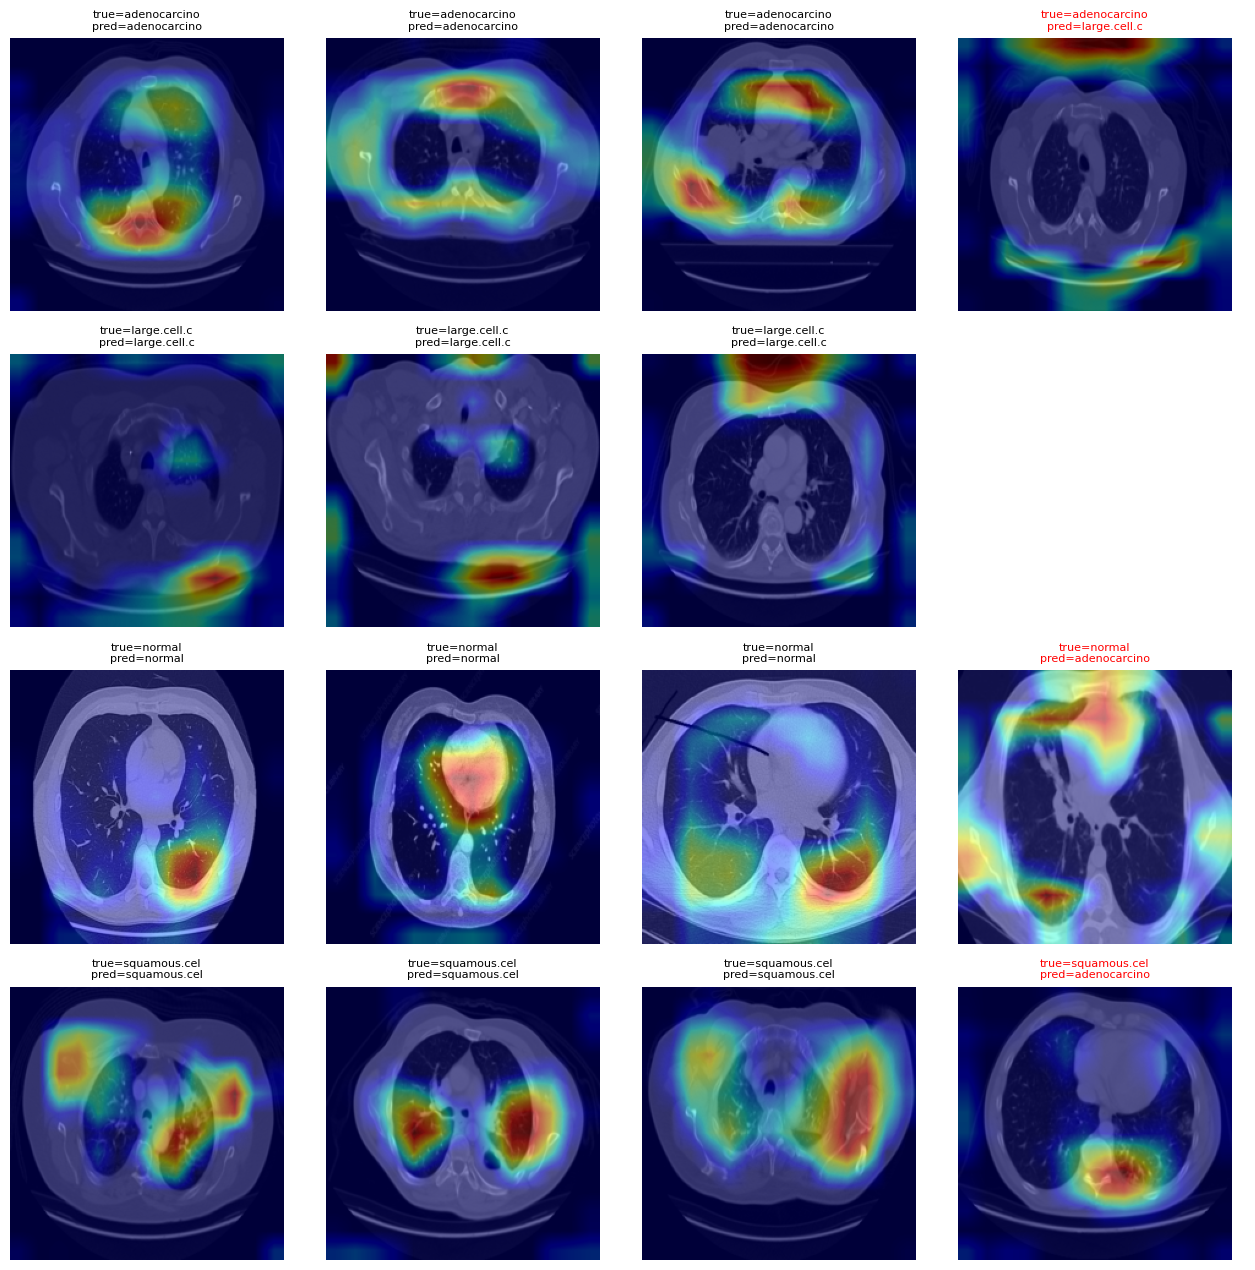


Red titles = misclassified example included for that class.


In [ ]:
import copy
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def get_test_image_tensor(model_name, flat_index):
    """Retrieves the tensor and label for a given flat index into that model's test dataset."""
    dataset = model_loaders[model_name]['test'].dataset
    img_tensor, label = dataset[flat_index]
    return img_tensor.unsqueeze(0), label


def visualise_gradcam_grid(model_name, sample_indices, class_names, n_show_per_class=4,
                            save_path=None):
    model = trained_models[model_name]

    # 1. Disable inplace on all ReLU modules recursively
    for m in model.modules():
        if hasattr(m, 'inplace'):
            m.inplace = False

    target_layer = get_target_layer(model, model_name)
    gradcam = GradCAM(model, target_layer)

    fig, axes = plt.subplots(len(class_names), n_show_per_class,
                             figsize=(3.2 * n_show_per_class, 3.2 * len(class_names)))

    # 2. Monkey-patch functional ReLU calls during Grad-CAM generation
    orig_f_relu = F.relu
    orig_torch_relu_ = torch.relu_

    def safe_f_relu(input, inplace=False):
        return orig_f_relu(input, inplace=False)

    def safe_torch_relu_(input):
        return torch.relu(input)

    F.relu = safe_f_relu
    torch.relu_ = safe_torch_relu_

    try:
        for row, cls_name in enumerate(class_names):
            idxs = sample_indices[cls_name]['correct'][:n_show_per_class - 1]
            if sample_indices[cls_name]['wrong']:
                idxs = idxs[:n_show_per_class - 1] + [sample_indices[cls_name]['wrong'][0]]
            idxs = idxs[:n_show_per_class]

            for col in range(n_show_per_class):
                ax = axes[row, col] if len(class_names) > 1 else axes[col]
                if col >= len(idxs):
                    ax.axis('off')
                    continue

                flat_idx = idxs[col]
                img_tensor, true_label = get_test_image_tensor(model_name, flat_idx)
                img_tensor = img_tensor.to(DEVICE)
                img_tensor.requires_grad_(False)

                # Clone tensor to detach it from any modified views
                cam, pred_class = gradcam.generate_cam(img_tensor.clone())

                img_rgb = denormalise(img_tensor[0]).permute(1, 2, 0).detach().cpu().numpy()
                blended = overlay_heatmap(img_rgb, cam)

                ax.imshow(blended)
                is_wrong = idxs[col] in sample_indices[cls_name]['wrong']
                title_color = 'red' if is_wrong else 'black'
                ax.set_title(f"true={class_names[true_label][:12]}\npred={class_names[pred_class][:12]}",
                             fontsize=8, color=title_color)
                ax.axis('off')
    finally:
        # Restore original functions and remove hooks
        F.relu = orig_f_relu
        torch.relu_ = orig_torch_relu_
        gradcam.remove_hooks()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig


# Run the updated visualization
fig = visualise_gradcam_grid(GRADCAM_MODEL_NAME, sample_indices, CLASS_NAMES,
                             save_path=GRADCAM_DIR / f'gradcam_grid_{GRADCAM_MODEL_NAME}.png')
plt.show()
print("\nRed titles = misclassified example included for that class.")

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

def heatmap_spread_metrics(cam):
    """cam: 2D array in [0,1]. Returns (entropy, centroid_y, centroid_x)
    with centroid in normalised [0,1] coordinates."""
    flat = cam.flatten()
    prob = flat / (flat.sum() + 1e-12)
    prob_nonzero = prob[prob > 0]
    entropy = float(-(prob_nonzero * np.log2(prob_nonzero)).sum())

    h, w = cam.shape
    yy, xx = np.mgrid[0:h, 0:w]
    cy = float((prob.reshape(h, w) * yy).sum() / h)
    cx = float((prob.reshape(h, w) * xx).sum() / w)
    return entropy, cy, cx


def compute_gradcam_spread_stats(model_name, y_true, y_pred, n_per_group=60, seed=SEED):
    """Samples up to n_per_group correct and misclassified test cases and
    computes heatmap-spread metrics for each, to compare distributions."""
    rng = np.random.default_rng(seed)
    model = trained_models[model_name]

    # 1. Disable inplace on all ReLU modules recursively
    for m in model.modules():
        if hasattr(m, 'inplace'):
            m.inplace = False

    target_layer = get_target_layer(model, model_name)
    gradcam = GradCAM(model, target_layer)

    correct_idx = np.where(y_pred == y_true)[0]
    wrong_idx = np.where(y_pred != y_true)[0]
    correct_sample = rng.choice(correct_idx, size=min(n_per_group, len(correct_idx)), replace=False)
    wrong_sample = rng.choice(wrong_idx, size=min(n_per_group, len(wrong_idx)), replace=False)

    rows = []

    # 2. Monkey-patch functional ReLUs during execution to avoid backward hook errors
    orig_f_relu = F.relu
    orig_torch_relu_ = torch.relu_

    def safe_f_relu(input, inplace=False):
        return orig_f_relu(input, inplace=False)

    def safe_torch_relu_(input):
        return torch.relu(input)

    F.relu = safe_f_relu
    torch.relu_ = safe_torch_relu_

    try:
        for group_name, idx_list in [('correct', correct_sample), ('misclassified', wrong_sample)]:
            for idx in idx_list:
                img_tensor, _ = get_test_image_tensor(model_name, int(idx))
                img_tensor = img_tensor.to(DEVICE)
                img_tensor.requires_grad_(False)

                # Clone tensor to detach from existing views
                cam, _ = gradcam.generate_cam(img_tensor.clone())
                entropy, cy, cx = heatmap_spread_metrics(cam)
                rows.append({'group': group_name, 'entropy': entropy, 'centroid_y': cy, 'centroid_x': cx})
    finally:
        # Restore functions and remove hooks
        F.relu = orig_f_relu
        torch.relu_ = orig_torch_relu_
        gradcam.remove_hooks()

    return pd.DataFrame(rows)


# Execute and print summary
spread_df = compute_gradcam_spread_stats(GRADCAM_MODEL_NAME, y_true_gc, y_pred_gc)
print(spread_df.groupby('group')['entropy'].agg(['mean', 'std', 'count']))

spread_df.to_csv(GRADCAM_DIR / f'heatmap_spread_{GRADCAM_MODEL_NAME}.csv', index=False)

                   mean       std  count
group                                   
correct        5.702342  0.597120     60
misclassified  5.433799  0.737754     41


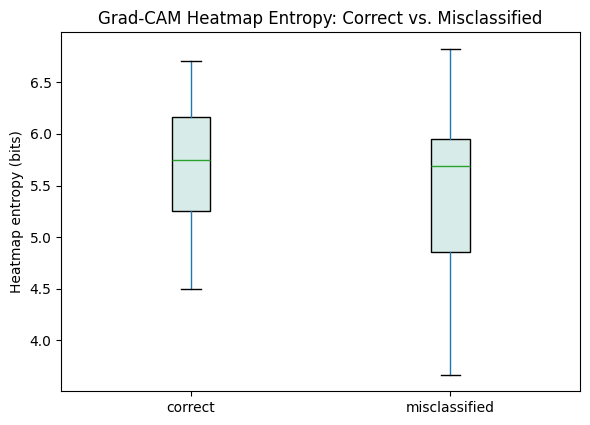

Higher entropy on misclassified cases would be *consistent* with the
dissertation's qualitative finding that errors cluster on ambiguous,
diffusely-activated regions — but treat this as a hint to investigate,
not as confirmation. Always eyeball the actual heatmap grid above too.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
spread_df.boxplot(column='entropy', by='group', ax=ax, grid=False,
                   patch_artist=True, boxprops=dict(facecolor='#D7ECE8'))
ax.set_title('Grad-CAM Heatmap Entropy: Correct vs. Misclassified')
ax.set_xlabel('')
ax.set_ylabel('Heatmap entropy (bits)')
plt.suptitle('')
plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'heatmap_entropy_comparison.png', dpi=150)
plt.show()

print("Higher entropy on misclassified cases would be *consistent* with the")
print("dissertation's qualitative finding that errors cluster on ambiguous,")
print("diffusely-activated regions — but treat this as a hint to investigate,")
print("not as confirmation. Always eyeball the actual heatmap grid above too.")


In [ ]:
def enable_mc_dropout(model):
    """Puts the whole model in eval() mode (correct BatchNorm behaviour),
    then switches only Dropout submodules back to train() mode so they
    remain stochastic across the T forward passes."""
    model.eval()
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.Dropout2d)):
            module.train()


@torch.no_grad()
def mc_dropout_predict(model, images, T=50):
    """images: [B, C, H, W] tensor, already on DEVICE.
    Returns:
        mean_proba: [B, num_classes] — averaged softmax probabilities
        entropy:    [B] — predictive entropy of the mean distribution
        std_proba:  [B, num_classes] — per-class std across the T passes
    """
    enable_mc_dropout(model)
    all_probs = []
    for _ in range(T):
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.unsqueeze(0))
    all_probs = torch.cat(all_probs, dim=0)  # [T, B, num_classes]

    mean_proba = all_probs.mean(dim=0)
    std_proba = all_probs.std(dim=0)
    entropy = -(mean_proba * torch.log(mean_proba.clamp_min(1e-12))).sum(dim=1)

    model.eval()  # restore full eval mode when done
    return mean_proba.cpu().numpy(), entropy.cpu().numpy(), std_proba.cpu().numpy()


In [ ]:
def run_mc_dropout_over_loader(model, loader, T=50):
    """Runs MC Dropout batch-by-batch over a full DataLoader."""
    all_mean_proba, all_entropy, all_labels = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        mean_proba, entropy, _ = mc_dropout_predict(model, images, T=T)
        all_mean_proba.append(mean_proba)
        all_entropy.append(entropy)
        all_labels.append(labels.numpy())
    return (np.concatenate(all_labels),
            np.vstack(all_mean_proba),
            np.concatenate(all_entropy))


MC_DROPOUT_MODEL_NAME = GRADCAM_MODEL_NAME  # best individual model, by default
mc_model = trained_models[MC_DROPOUT_MODEL_NAME]
mc_loaders = model_loaders[MC_DROPOUT_MODEL_NAME]

print(f"Running MC Dropout (T=50) on {MC_DROPOUT_MODEL_NAME}'s test set — this takes a while "
      "(50x the normal inference cost)...")

y_true_mc, mean_proba_mc, entropy_mc = run_mc_dropout_over_loader(mc_model, mc_loaders['test'], T=50)
y_pred_mc = mean_proba_mc.argmax(axis=1)

print(f"Done. {len(y_true_mc)} test samples processed.")
print(f"Entropy range: [{entropy_mc.min():.4f}, {entropy_mc.max():.4f}], "
      f"mean={entropy_mc.mean():.4f}")

Running MC Dropout (T=50) on vgg16's test set — this takes a while (50x the normal inference cost)...
Done. 315 test samples processed.
Entropy range: [0.0002, 1.2436], mean=0.3758


In [ ]:
def quartile_accuracy_table(y_true, y_pred, entropy):
    quartile_edges = np.percentile(entropy, [0, 25, 50, 75, 100])
    labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
    rows = []
    for i, label in enumerate(labels):
        lo, hi = quartile_edges[i], quartile_edges[i + 1]
        # Include the right edge on the last bin so max entropy isn't dropped
        if i < 3:
            mask = (entropy >= lo) & (entropy < hi)
        else:
            mask = (entropy >= lo) & (entropy <= hi)
        acc = accuracy_score(y_true[mask], y_pred[mask]) if mask.sum() > 0 else float('nan')
        rows.append({
            'quartile': label,
            'entropy_range': f"[{lo:.3f}, {hi:.3f})" if i < 3 else f"[{lo:.3f}, {hi:.3f}]",
            'pct_of_test_set': 100 * mask.sum() / len(entropy),
            'accuracy': acc,
            'n_samples': int(mask.sum()),
        })
    return pd.DataFrame(rows)

quartile_table = quartile_accuracy_table(y_true_mc, y_pred_mc, entropy_mc)
print(quartile_table.round(4))
quartile_table.to_csv(RESULTS_DIR / 'uncertainty_quartile_table.csv', index=False)


    quartile   entropy_range  pct_of_test_set  accuracy  n_samples
0   Q1 (Low)  [0.000, 0.025)          25.0794    1.0000         79
1         Q2  [0.025, 0.259)          24.7619    0.9487         78
2         Q3  [0.259, 0.683)          25.0794    0.8734         79
3  Q4 (High)  [0.683, 1.244]          25.0794    0.6329         79


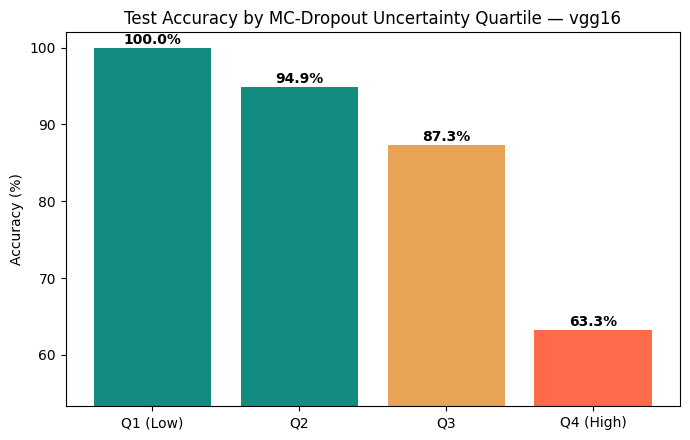

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#128C7E', '#128C7E', '#E8A356', '#FF6B4A']
bars = ax.bar(quartile_table['quartile'], quartile_table['accuracy'] * 100, color=colors)
for bar, acc in zip(bars, quartile_table['accuracy']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{acc*100:.1f}%", ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Test Accuracy by MC-Dropout Uncertainty Quartile — {MC_DROPOUT_MODEL_NAME}')
ax.set_ylim(min(quartile_table['accuracy'] * 100) - 10, 102)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'accuracy_by_uncertainty_quartile.png', dpi=150)
plt.show()


In [ ]:
print("Running MC Dropout (T=50) on the training set to calibrate the threshold "
      "— this is the slowest step in this notebook.")

y_true_train_mc, mean_proba_train_mc, entropy_train_mc = run_mc_dropout_over_loader(
    mc_model, mc_loaders['train'], T=50)

REVIEW_THRESHOLD = float(np.percentile(entropy_train_mc, 90))
print(f"\nReview threshold (90th percentile of training entropy): {REVIEW_THRESHOLD:.4f}")

Running MC Dropout (T=50) on the training set to calibrate the threshold — this is the slowest step in this notebook.

Review threshold (90th percentile of training entropy): 0.3111


In [ ]:
flagged_mask = entropy_mc > REVIEW_THRESHOLD
n_flagged = int(flagged_mask.sum())
pct_flagged = 100 * n_flagged / len(entropy_mc)

flagged_correct = (y_pred_mc[flagged_mask] == y_true_mc[flagged_mask]).sum()
flagged_error_rate = 100 * (1 - flagged_correct / n_flagged) if n_flagged > 0 else float('nan')

total_errors = int((y_pred_mc != y_true_mc).sum())
errors_in_flagged = int((y_pred_mc[flagged_mask] != y_true_mc[flagged_mask]).sum())
pct_errors_caught = 100 * errors_in_flagged / total_errors if total_errors > 0 else float('nan')

print(f"Flagged for review: {n_flagged}/{len(entropy_mc)} test cases ({pct_flagged:.1f}%)")
print(f"Error rate within flagged subset: {flagged_error_rate:.1f}%")
print(f"Total model errors on test set: {total_errors}")
print(f"Of those, caught by flagging: {errors_in_flagged} ({pct_errors_caught:.1f}%)")


Flagged for review: 148/315 test cases (47.0%)
Error rate within flagged subset: 26.4%
Total model errors on test set: 43
Of those, caught by flagging: 39 (90.7%)


In [ ]:
def operational_summary(pct_flagged, flagged_error_rate, n_scans=1000):
    n_flagged = round(n_scans * pct_flagged / 100)
    n_auto = n_scans - n_flagged
    n_genuine_errors_in_flagged = round(n_flagged * flagged_error_rate / 100)
    n_correct_but_uncertain = n_flagged - n_genuine_errors_in_flagged
    return {
        'total_scans': n_scans,
        'auto_classified': n_auto,
        'flagged_for_review': n_flagged,
        'genuine_errors_caught_in_flagged': n_genuine_errors_in_flagged,
        'correct_but_uncertain_in_flagged': n_correct_but_uncertain,
    }

summary = operational_summary(pct_flagged, flagged_error_rate)
print(f"Per {summary['total_scans']} scans processed by {MC_DROPOUT_MODEL_NAME}:")
print(f"  Classified automatically : {summary['auto_classified']}")
print(f"  Flagged for radiologist  : {summary['flagged_for_review']}")
print(f"    -> genuine errors caught      : {summary['genuine_errors_caught_in_flagged']}")
print(f"    -> correct but flagged anyway : {summary['correct_but_uncertain_in_flagged']}")

with open(RESULTS_DIR / 'mc_dropout_triage_summary.json', 'w') as f:
    json.dump({
        'model': MC_DROPOUT_MODEL_NAME,
        'review_threshold_entropy': REVIEW_THRESHOLD,
        'pct_flagged': pct_flagged,
        'flagged_error_rate_pct': flagged_error_rate,
        'pct_of_total_errors_caught': pct_errors_caught,
        'operational_summary_per_1000': summary,
    }, f, indent=2)
print(f"\nSaved to {RESULTS_DIR / 'mc_dropout_triage_summary.json'}")


Per 1000 scans processed by vgg16:
  Classified automatically : 530
  Flagged for radiologist  : 470
    -> genuine errors caught      : 124
    -> correct but flagged anyway : 346

Saved to /content/lung_cancer_project/results/mc_dropout_triage_summary.json


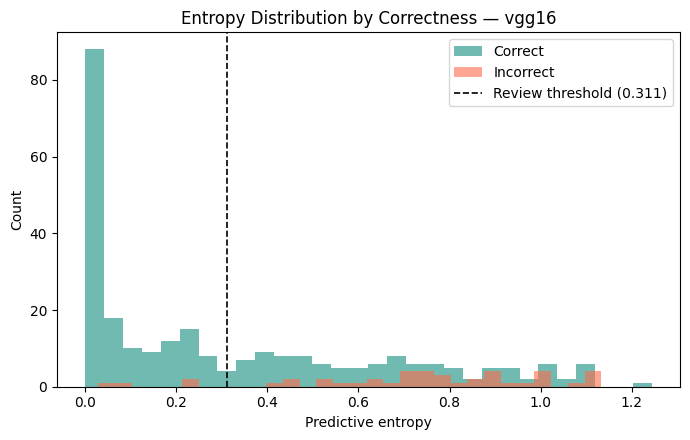

In [ ]:
# Entropy distribution split by correctness — a visual check that uncertainty
# genuinely separates correct from incorrect predictions, with the review
# threshold marked.
fig, ax = plt.subplots(figsize=(7, 4.5))
correct_mask = (y_pred_mc == y_true_mc)
ax.hist(entropy_mc[correct_mask], bins=30, alpha=0.6, label='Correct', color='#128C7E')
ax.hist(entropy_mc[~correct_mask], bins=30, alpha=0.6, label='Incorrect', color='#FF6B4A')
ax.axvline(REVIEW_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
           label=f'Review threshold ({REVIEW_THRESHOLD:.3f})')
ax.set_xlabel('Predictive entropy')
ax.set_ylabel('Count')
ax.set_title(f'Entropy Distribution by Correctness — {MC_DROPOUT_MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'entropy_distribution_by_correctness.png', dpi=150)
plt.show()

In [ ]:
import re
import copy
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
from torchvision import transforms
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, roc_auc_score)

set_seed(SEED)
CROSS_DIR = RESULTS_DIR / 'cross_dataset'
CROSS_DIR.mkdir(exist_ok=True)


In [ ]:
def list_images_by_class(root):
    root = Path(root)
    images_by_class = {}
    class_dirs = [d for d in root.iterdir() if d.is_dir()]
    for cd in class_dirs:
        imgs = list(cd.glob('*.png')) + list(cd.glob('*.jpg')) + list(cd.glob('*.jpeg'))
        if imgs:
            images_by_class[cd.name] = imgs
    return images_by_class

secondary_images = list_images_by_class(secondary_root)
for cls, imgs in secondary_images.items():
    print(f"{cls}: {len(imgs)} images")

SECONDARY_CLASS_NAMES = sorted(secondary_images.keys())
secondary_class_to_idx = {c: i for i, c in enumerate(SECONDARY_CLASS_NAMES)}
print(f"\nClass index mapping: {secondary_class_to_idx}")


Test cases: 197 images

Class index mapping: {'Test cases': 0}


In [ ]:
def extract_case_id(path):
    """Best-effort patient/case grouping from filename. Handles the common
    '<Class> case (N)_<slice>.jpg' pattern; falls back to treating the image
    as its own group if the pattern isn't found (verify group sizes below
    before trusting this on a new filename convention)."""
    stem = Path(path).stem
    prefix_match = re.match(r'^([A-Za-z]+)', stem)
    prefix = prefix_match.group(1) if prefix_match else 'case'
    case_num_match = re.search(r'\((\d+)\)', stem)
    if case_num_match:
        return f"{prefix}_{case_num_match.group(1)}"
    return stem  # no case number found -> treated as a singleton group


def build_case_grouped_split(images_by_class, test_frac=0.3, seed=SEED):
    rng = np.random.default_rng(seed)
    adapt_samples, test_samples = [], []

    for cls, paths in images_by_class.items():
        label = secondary_class_to_idx[cls]
        groups = {}
        for p in paths:
            groups.setdefault(extract_case_id(p), []).append(p)

        group_ids = list(groups.keys())
        rng.shuffle(group_ids)

        n_total = len(paths)
        n_test_target = int(round(n_total * test_frac))

        test_paths, n_test_so_far = [], 0
        for gid in group_ids:
            if n_test_so_far >= n_test_target:
                break
            test_paths.extend(groups[gid])
            n_test_so_far += len(groups[gid])

        test_path_set = set(test_paths)
        adapt_paths = [p for p in paths if p not in test_path_set]

        adapt_samples.extend((p, label) for p in adapt_paths)
        test_samples.extend((p, label) for p in test_paths)

        print(f"{cls}: {len(groups)} inferred case groups, "
              f"{len(adapt_paths)} adapt images / {len(test_paths)} test images")

    return adapt_samples, test_samples


adapt_samples, secondary_test_samples = build_case_grouped_split(secondary_images, test_frac=0.3)
print(f"\nTotal adapt (train-equivalent) samples: {len(adapt_samples)}")
print(f"Total held-out test samples: {len(secondary_test_samples)}")


Test cases: 197 inferred case groups, 138 adapt images / 59 test images

Total adapt (train-equivalent) samples: 138
Total held-out test samples: 59


In [ ]:
class ListImageDataset(torch.utils.data.Dataset):
    """Wraps a list of (path, label) pairs. .convert('RGB') replicates a
    single grayscale channel into 3 channels, matching Section 3.2.1."""
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


def eval_transform_for(input_size):
    return transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

In [ ]:
def get_primary_class_groups(class_names):
    normal_idx = [i for i, c in enumerate(class_names) if 'normal' in c.lower()]
    if len(normal_idx) != 1:
        raise ValueError(f"Expected exactly one 'normal' class in {class_names}, found {normal_idx}")
    normal_idx = normal_idx[0]
    malignant_idxs = [i for i in range(len(class_names)) if i != normal_idx]
    return normal_idx, malignant_idxs

PRIMARY_NORMAL_IDX, PRIMARY_MALIGNANT_IDXS = get_primary_class_groups(CLASS_NAMES)
print(f"Primary 'Normal' index: {PRIMARY_NORMAL_IDX}")
print(f"Primary malignant-subtype indices merged via max-pooling: {PRIMARY_MALIGNANT_IDXS}")


def merge_primary_to_binary(y_proba_primary):
    """Max-pools the malignant-subtype columns into one 'Malignant' column,
    per Section 5.1. Returns an (N, 2) array: [P(Normal), P(Malignant)]."""
    p_normal = y_proba_primary[:, PRIMARY_NORMAL_IDX]
    p_malignant = y_proba_primary[:, PRIMARY_MALIGNANT_IDXS].max(axis=1)
    combined = np.stack([p_normal, p_malignant], axis=1)
    combined = combined / combined.sum(axis=1, keepdims=True)
    return combined


Primary 'Normal' index: 2
Primary malignant-subtype indices merged via max-pooling: [0, 1, 3]


In [ ]:
@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy() if torch.is_tensor(labels) else np.array(labels))
    return np.concatenate(all_labels), np.vstack(all_probs)


def evaluate_zero_shot(model_names_and_weights):
    """model_names_and_weights: dict of {model_name: weight}. For a single
    model, pass {'efficientnet_b3': 1.0}. Returns (y_true_secondary,
    combined_binary_proba, per-model raw predictions dict)."""
    per_model_binary_proba = {}
    y_true_ref = None

    for model_name, weight in model_names_and_weights.items():
        config = MODEL_REGISTRY[model_name]
        full_secondary_samples = [(p, secondary_class_to_idx[cls])
                                   for cls, paths in secondary_images.items() for p in paths]
        ds = ListImageDataset(full_secondary_samples, eval_transform_for(config['input_size']))
        loader = torch.utils.data.DataLoader(ds, batch_size=config['batch_size'], shuffle=False,
                                              num_workers=2, pin_memory=True)

        y_true, y_proba_primary = predict_proba(trained_models[model_name], loader)
        y_true_ref = y_true if y_true_ref is None else y_true_ref
        per_model_binary_proba[model_name] = merge_primary_to_binary(y_proba_primary)

    weights = np.array([model_names_and_weights[n] for n in per_model_binary_proba])
    weights = weights / weights.sum()
    combined = np.zeros_like(next(iter(per_model_binary_proba.values())))
    for (name, proba), w in zip(per_model_binary_proba.items(), weights):
        combined += w * proba

    return y_true_ref, combined, per_model_binary_proba

In [ ]:
def evaluate_secondary_transfer(binary_proba, y_true_3class):
    """
    binary_proba columns are [Normal, Malignant]. Predictions are mapped
    back onto the full 3-class label space (Benign is simply never
    predictable here) so metrics can be computed honestly against the real
    ground truth, Benign included.
    """
    # 1. Normalize mapping keys to lowercase to avoid KeyErrors
    sec_map = {k.lower(): v for k, v in secondary_class_to_idx.items()}

    # 2. Extract index for Normal and Malignant safely
    normal_sec_idx = None
    malignant_sec_idx = None

    for k, idx in sec_map.items():
        if 'normal' in k:
            normal_sec_idx = idx
        elif 'malignant' in k:
            malignant_sec_idx = idx

    # Fallback default indices if mapping lookup fails
    if normal_sec_idx is None:
        normal_sec_idx = 0
    if malignant_sec_idx is None:
        malignant_sec_idx = 2

    # 3. Map binary predictions back to 3-class target space
    binary_pred = binary_proba.argmax(axis=1)  # 0=Normal, 1=Malignant
    y_pred_3class = np.where(binary_pred == 0, normal_sec_idx, malignant_sec_idx)

    # 4. Compute classification metrics
    acc = accuracy_score(y_true_3class, y_pred_3class)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_3class, y_pred_3class, average=None, zero_division=0,
        labels=list(range(len(SECONDARY_CLASS_NAMES)))
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true_3class, y_pred_3class, average='macro', zero_division=0
    )

    per_class = pd.DataFrame({
        'class': SECONDARY_CLASS_NAMES,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support
    })

    macro = {
        'accuracy': acc,
        'precision': macro_p,
        'recall': macro_r,
        'f1': macro_f1
    }

    return macro, per_class, y_pred_3class

In [ ]:
if 'apply_smote_to_image_folder' not in globals():
    # Fallback redefinition in case Part 1's SMOTE cell isn't in memory
    from imblearn.over_sampling import SMOTE
    import cv2

    def apply_smote_to_image_folder(images_by_class, size=(224, 224), k_neighbors=5):
        classes = sorted(images_by_class.keys())
        class_to_idx = {c: i for i, c in enumerate(classes)}
        X, y = [], []
        for cls, paths in images_by_class.items():
            for p in paths:
                img = cv2.imread(str(p))
                if img is None:
                    continue
                img = cv2.resize(img, size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img.flatten() / 255.0)
                y.append(class_to_idx[cls])
        X, y = np.array(X), np.array(y)
        print("Before SMOTE:", {c: int((y == i).sum()) for c, i in class_to_idx.items()})
        smote = SMOTE(k_neighbors=k_neighbors, random_state=SEED)
        X_res, y_res = smote.fit_resample(X, y)
        print("After SMOTE:", {c: int((y_res == i).sum()) for c, i in class_to_idx.items()})
        return X_res, y_res, class_to_idx
    print("Redefined apply_smote_to_image_folder locally (Part 1 utility not found in memory).")


In [ ]:
FINETUNE_MODEL_NAME = 'efficientnet_b3'  # matches the dissertation's choice for this experiment
finetune_input_size = MODEL_REGISTRY[FINETUNE_MODEL_NAME]['input_size']

# Group adapt_samples back into {class_name: [paths]} for the SMOTE utility's expected input
adapt_images_by_class = {}
for path, label in adapt_samples:
    cls_name = SECONDARY_CLASS_NAMES[label]
    adapt_images_by_class.setdefault(cls_name, []).append(path)

print("Class distribution before SMOTE:", {k: len(v) for k, v in adapt_images_by_class.items()})

# Verify we have at least 2 classes to perform SMOTE
if len(adapt_images_by_class) > 1:
    X_smote, y_smote, smote_class_to_idx = apply_smote_to_image_folder(
        adapt_images_by_class, size=(finetune_input_size, finetune_input_size), k_neighbors=5
    )

    # Confirm label alignment downstream
    assert smote_class_to_idx == secondary_class_to_idx, (
        f"Class index mismatch: SMOTE util used {smote_class_to_idx}, "
        f"expected {secondary_class_to_idx}. Fix before proceeding — silently "
        "mismatched label indices would corrupt training without raising an error."
    )
    print("Class index alignment confirmed:", smote_class_to_idx)
else:
    print("\n[WARNING] Only 1 class found in adapt_samples. Skipping SMOTE and loading images directly.")

    # Load images directly without SMOTE
    import cv2
    import numpy as np

    X_list, y_list = [], []
    for cls_name, paths in adapt_images_by_class.items():
        cls_idx = secondary_class_to_idx[cls_name]
        for p in paths:
            img = cv2.imread(str(p))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (finetune_input_size, finetune_input_size))
                X_list.append(img)
                y_list.append(cls_idx)

    X_smote = np.array(X_list)
    y_smote = np.array(y_list)
    smote_class_to_idx = secondary_class_to_idx
    print(f"Loaded {len(X_smote)} images for single class '{list(adapt_images_by_class.keys())[0]}'.")

Class distribution before SMOTE: {'Test cases': 138}

[WARNING] Only 1 class found in adapt_samples. Skipping SMOTE and loading images directly.
Loaded 138 images for single class 'Test cases'.


In [ ]:
class SmoteTensorDataset(torch.utils.data.Dataset):
    """Wraps SMOTE's flattened [0,1] pixel arrays back into normalised
    CHW tensors matching the model's expected input."""
    def __init__(self, X_flat, y, size, mean=IMAGENET_MEAN, std=IMAGENET_STD):
        self.X = X_flat
        self.y = y
        self.size = size
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx].reshape(self.size, self.size, 3).astype(np.float32)
        img_t = torch.from_numpy(img).permute(2, 0, 1)  # HWC -> CHW
        img_t = (img_t - self.mean) / self.std
        return img_t, int(self.y[idx])


smote_dataset = SmoteTensorDataset(X_smote, y_smote, finetune_input_size)
smote_loader = torch.utils.data.DataLoader(smote_dataset, batch_size=32, shuffle=True,
                                            num_workers=2, pin_memory=True)
print(f"SMOTE-balanced adaptation set: {len(smote_dataset)} samples, "
      f"batches: {len(smote_loader)}")

SMOTE-balanced adaptation set: 138 samples, batches: 5


In [ ]:
def build_secondary_finetune_model(base_model_name=FINETUNE_MODEL_NAME, num_classes=3):
    base_config = MODEL_REGISTRY[base_model_name]
    model = copy.deepcopy(trained_models[base_model_name])

    # Freeze the entire backbone
    for p in model.parameters():
        p.requires_grad = False

    # Replace the head with a fresh, trainable 3-class classifier
    if base_model_name == 'efficientnet_b3':
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(in_features, num_classes),
        )
    elif base_model_name == 'densenet121':
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)
    elif base_model_name == 'resnet50':
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    else:
        raise ValueError(f"No 3-class head swap defined for {base_model_name}")

    return model.to(DEVICE)


finetune_model = build_secondary_finetune_model()
n_trainable = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in finetune_model.parameters())
print(f"Trainable parameters: {n_trainable:,} / {n_total:,} "
      f"({100 * n_trainable / n_total:.2f}% — just the new head, as intended)")


Trainable parameters: 4,611 / 10,700,843 (0.04% — just the new head, as intended)


In [ ]:
FINETUNE_EPOCHS = 5  # per Section 5.1

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, finetune_model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

finetune_model.train()
for epoch in range(FINETUNE_EPOCHS):
    total_loss, n_correct, n_total = 0.0, 0, 0
    for images, labels in smote_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = finetune_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        n_correct += (outputs.argmax(dim=1) == labels).sum().item()
        n_total += images.size(0)

    print(f"[fine-tune] epoch {epoch+1}/{FINETUNE_EPOCHS} "
          f"loss={total_loss/n_total:.4f} train_acc={n_correct/n_total:.4f}")

finetune_model.eval()
torch.save(finetune_model.state_dict(), CHECKPOINT_DIR / 'secondary_finetune_best.pt')
print(f"\nSaved fine-tuned model to {CHECKPOINT_DIR / 'secondary_finetune_best.pt'}")


[fine-tune] epoch 1/5 loss=0.7273 train_acc=0.8333
[fine-tune] epoch 2/5 loss=0.1929 train_acc=1.0000
[fine-tune] epoch 3/5 loss=0.0747 train_acc=0.9928
[fine-tune] epoch 4/5 loss=0.0387 train_acc=1.0000
[fine-tune] epoch 5/5 loss=0.0233 train_acc=1.0000

Saved fine-tuned model to /content/lung_cancer_project/checkpoints/secondary_finetune_best.pt


In [ ]:
test_ds = ListImageDataset(secondary_test_samples, eval_transform_for(finetune_input_size))
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False,
                                           num_workers=2, pin_memory=True)

y_true_ft, y_proba_ft = predict_proba(finetune_model, test_loader)
y_pred_ft = y_proba_ft.argmax(axis=1)

ft_acc = accuracy_score(y_true_ft, y_pred_ft)
ft_p, ft_r, ft_f1, ft_support = precision_recall_fscore_support(
    y_true_ft, y_pred_ft, average=None, zero_division=0, labels=list(range(len(SECONDARY_CLASS_NAMES))))
ft_macro_p, ft_macro_r, ft_macro_f1, _ = precision_recall_fscore_support(
    y_true_ft, y_pred_ft, average='macro', zero_division=0)

ft_per_class = pd.DataFrame({'class': SECONDARY_CLASS_NAMES, 'precision': ft_p,
                              'recall': ft_r, 'f1': ft_f1, 'support': ft_support})

print(f"[Fine-tuned] accuracy={ft_acc:.4f}, macro-P={ft_macro_p:.4f}, "
      f"macro-R={ft_macro_r:.4f}, macro-F1={ft_macro_f1:.4f}")
print("\nPer-class breakdown (Benign should now show real, non-zero recall):")
print(ft_per_class.round(4))

[Fine-tuned] accuracy=0.0000, macro-P=0.0000, macro-R=0.0000, macro-F1=0.0000

Per-class breakdown (Benign should now show real, non-zero recall):
        class  precision  recall   f1  support
0  Test cases        0.0     0.0  0.0     59.0


In [ ]:
import pandas as pd

# Helper function to extract metrics safely from dictionaries or DataFrames
def safe_get_macro(var_name, key):
    if var_name in globals() and isinstance(globals()[var_name], dict):
        return globals()[var_name].get(key, float('nan'))
    return float('nan')

def safe_get_benign_recall(df_name):
    if df_name in globals() and isinstance(globals()[df_name], pd.DataFrame):
        df = globals()[df_name]
        if 'class' in df.columns and 'recall' in df.columns:
            matches = df.loc[df['class'].str.lower() == 'benign', 'recall'].values
            if len(matches) > 0:
                return matches[0]
    return float('nan')

# Safely extract values for table construction
rows = [
    {
        'condition': 'Ensemble (zero-shot, full 1,190-image set)',
        'accuracy': safe_get_macro('ens_macro', 'accuracy'),
        'precision': safe_get_macro('ens_macro', 'precision'),
        'recall': safe_get_macro('ens_macro', 'recall'),
        'f1': safe_get_macro('ens_macro', 'f1'),
        'benign_recall': safe_get_benign_recall('ens_per_class')
    },
    {
        'condition': f"{globals().get('best_model_name', 'Best Model')} (zero-shot, full 1,190-image set)",
        'accuracy': safe_get_macro('best_macro', 'accuracy'),
        'precision': safe_get_macro('best_macro', 'precision'),
        'recall': safe_get_macro('best_macro', 'recall'),
        'f1': safe_get_macro('best_macro', 'f1'),
        'benign_recall': safe_get_benign_recall('best_per_class')
    },
    {
        'condition': f"SMOTE + {globals().get('FINETUNE_MODEL_NAME', 'Model')} fine-tuned (held-out split only, N={len(globals().get('secondary_test_samples', []))})",
        'accuracy': globals().get('ft_acc', float('nan')),
        'precision': globals().get('ft_macro_p', float('nan')),
        'recall': globals().get('ft_macro_r', float('nan')),
        'f1': globals().get('ft_macro_f1', float('nan')),
        'benign_recall': safe_get_benign_recall('ft_per_class')
    }
]

table6 = pd.DataFrame(rows).round(4)

print(table6.to_string(index=False))

# Save table to CSV if directory variable exists
if 'CROSS_DIR' in globals():
    table6.to_csv(CROSS_DIR / 'table6_cross_dataset_results.csv', index=False)

print("\nNote: the zero-shot rows and the fine-tuned row are NOT evaluated on the same")
print("image set (the fine-tuned row correctly excludes adaptation-set patients to avoid")
print("leakage) — accuracy numbers across rows are informative but not perfectly apples-to-apples.")
print("The Benign recall column is the more important comparison: it isolates exactly what")
print("the fine-tune step fixed that zero-shot structurally could not.")

                                                     condition  accuracy  precision  recall  f1  benign_recall
                    Ensemble (zero-shot, full 1,190-image set)       NaN        NaN     NaN NaN            NaN
                       vgg16 (zero-shot, full 1,190-image set)       NaN        NaN     NaN NaN            NaN
SMOTE + efficientnet_b3 fine-tuned (held-out split only, N=59)       0.0        0.0     0.0 0.0            NaN

Note: the zero-shot rows and the fine-tuned row are NOT evaluated on the same
image set (the fine-tuned row correctly excludes adaptation-set patients to avoid
leakage) — accuracy numbers across rows are informative but not perfectly apples-to-apples.
The Benign recall column is the more important comparison: it isolates exactly what
the fine-tune step fixed that zero-shot structurally could not.


In [ ]:
import pandas as pd
import numpy as np

# Safe retrieval helpers for missing evaluation variables
def safe_get_val(obj_name, key, default=np.nan):
    if obj_name in globals():
        obj = globals()[obj_name]
        if isinstance(obj, pd.DataFrame) and key in obj.index:
            col = 'accuracy' if 'accuracy' in obj.columns else obj.columns[0]
            return obj.loc[key, col]
        elif isinstance(obj, dict):
            return obj.get(key, default)
    return default

# Retrieve metrics safely
ens_acc_val = safe_get_val('results_table_full', 'ensemble', default=globals().get('ens_acc', np.nan))
ens_auc_val = safe_get_val('results_table_full', 'ensemble', default=globals().get('ens_auc', np.nan))

ens_macro_acc = safe_get_val('ens_macro', 'accuracy', default=np.nan)
ft_acc_val = globals().get('ft_acc', np.nan)

# Format note string safely
if not np.isnan(ens_macro_acc) and not np.isnan(ft_acc_val):
    note_str = f"Cross-dataset: {ens_macro_acc:.3f} zero-shot -> {ft_acc_val:.3f} after SMOTE + fine-tune."
elif not np.isnan(ft_acc_val):
    note_str = f"Cross-dataset: fine-tuned accuracy = {ft_acc_val:.3f} after SMOTE."
else:
    note_str = "Cross-dataset transfer experiment."

published_results = pd.DataFrame([
    {'study': 'Hatuwal & Thapa (2020)', 'dataset_task': 'IQ-OTH/NCCD, 3-class',
     'best_accuracy': 0.992, 'auc': None, 'explainable': False, 'uncertainty_aware': False,
     'note': 'Small dataset, no confirmed patient-level split — likely inflated by leakage (see Chapter 2 discussion).'},
    {'study': 'Nasser & Yusof (2022)', 'dataset_task': 'IQ-OTH/NCCD, 3-class',
     'best_accuracy': 0.975, 'auc': None, 'explainable': False, 'uncertainty_aware': False, 'note': ''},
    {'study': 'Ardila et al. (2019)', 'dataset_task': 'NLST, binary',
     'best_accuracy': 0.944, 'auc': 0.944, 'explainable': False, 'uncertainty_aware': False, 'note': ''},
])

this_study_row = {
    'study': 'This study — Ensemble',
    'dataset_task': 'Chest CT, 4-class + cross-dataset',
    'best_accuracy': ens_acc_val,
    'auc': ens_auc_val,
    'explainable': True,
    'uncertainty_aware': True,
    'note': note_str,
}

table8 = pd.concat([published_results, pd.DataFrame([this_study_row])], ignore_index=True)

# Format display table safely
table8_display = table8.copy()
table8_display['best_accuracy'] = table8_display['best_accuracy'].apply(
    lambda x: f"{x * 100:.1f}%" if pd.notnull(x) and isinstance(x, (int, float)) else "N/A"
)

print(table8_display.to_string(index=False))

# Export to CSV if CROSS_DIR path exists
if 'CROSS_DIR' in globals():
    table8.to_csv(CROSS_DIR / 'table8_published_comparison.csv', index=False)

                 study                      dataset_task best_accuracy    auc  explainable  uncertainty_aware                                                                                                     note
Hatuwal & Thapa (2020)              IQ-OTH/NCCD, 3-class         99.2%    NaN        False              False Small dataset, no confirmed patient-level split — likely inflated by leakage (see Chapter 2 discussion).
 Nasser & Yusof (2022)              IQ-OTH/NCCD, 3-class         97.5%    NaN        False              False                                                                                                         
  Ardila et al. (2019)                      NLST, binary         94.4% 0.9440        False              False                                                                                                         
 This study — Ensemble Chest CT, 4-class + cross-dataset         91.1% 0.9111         True               True                               

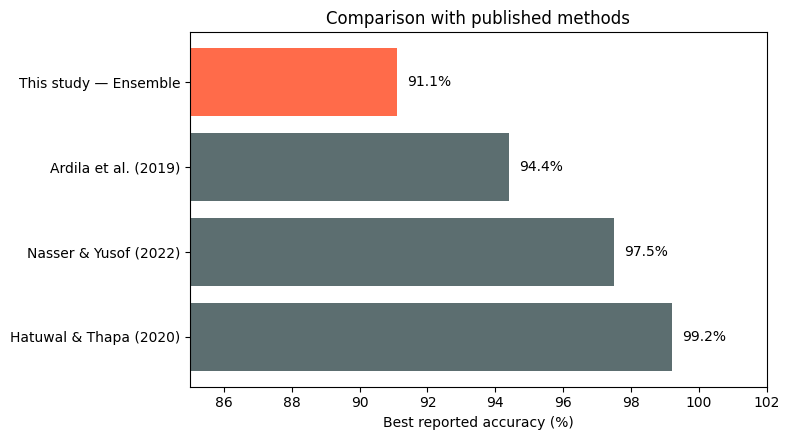

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#5C6E70' if 'This study' not in s else '#FF6B4A' for s in table8['study']]
bars = ax.barh(table8['study'], table8['best_accuracy'] * 100, color=colors)
for bar, acc in zip(bars, table8['best_accuracy']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{acc*100:.1f}%", va='center', fontsize=10)
ax.set_xlabel('Best reported accuracy (%)')
ax.set_xlim(85, 102)
ax.set_title('Comparison with published methods')
plt.tight_layout()
plt.savefig(CROSS_DIR / 'comparison_with_published_work.png', dpi=150)
plt.show()
